<a href="https://colab.research.google.com/github/amathie5/La-Nebuleuse/blob/main/SL_Project_VF%2BEV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sustainable Logistics Project for La Nébuleuse: VRP and FLP Optimization

# VRP
## 1. Context and Objectives
The objective of this project is to mathematically determine and optimize the logistics network of La Nébuleuse. The project is divided into two main phases:
1.  **Vehicle Routing Problem (VRP)**: Optimizing current delivery routes to minimize distances and operational costs, considering a heterogeneous fleet (VW Caddy, Ford Transit, Truck).
2.  **Facility Location Problem (FLP)**: Evaluating four distinct strategic scenarios (Status Quo, Production Consolidation in Renens, Forward Urban Hub in Lausanne, Outsourced Mega-Hub in Givisiez) using Mixed Integer Programming (MIP) to provide a data-driven recommendation for long-term growth.

## 2. Financial and Operational Assumptions
* **No Time Windows**: Deliveries are scheduled without strict time-of-day constraints.
* **Reverse Logistics**: Returns (empty kegs, pallets) are collected concurrently during delivery stops, effectively absorbed into the primary routing without generating additional trips.

In [1]:
!pip install ortools
!pip install folium

import pandas as pd
import numpy as np
import folium
import math
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import io
import os
from google.colab import files
from ortools.linear_solver import pywraplp
from ortools.constraint_solver import routing_enums_pb2, pywrapcp

# 1. Define the exact file names you expect
expected_files = ["données2025.xlsx", "packaging.xlsx", "matrice_distances_km.csv"]

# 2. Delete old versions if they exist in the Colab memory
for file_name in expected_files:
    if os.path.exists(file_name):
        os.remove(file_name)
        print("Removed old version: " + file_name)

# 3. Trigger the upload
print("\nPlease select your data files (CSV or Excel):")
uploaded = files.upload()

print("\nFiles successfully loaded:")
for file_name in uploaded.keys():
    print("- " + file_name)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 9.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 whi


Please select your data files (CSV or Excel):


Saving données2025.xlsx to données2025.xlsx
Saving matrice_distances_km.csv to matrice_distances_km.csv
Saving packaging.xlsx to packaging.xlsx

Files successfully loaded:
- données2025.xlsx
- matrice_distances_km.csv
- packaging.xlsx


## 3. Data Description and Operational Context

Before feeding data into the optimization models, it is critical to define the infrastructure, fleet capabilities, and demand profiles shaping La Nébuleuse's logistics.

### 3.1 Network Infrastructure (Facilities)
The company operates across two main logistical nodes:
* **Brasserie Renens (Production):** The primary brewing and packaging site. It has limited storage capacity (~150 pallet spaces). For the scope of the delivery routing problem, this site acts as a production source rather than the daily dispatch depot.
* **Entrepôt Crissier (Distribution Depot):** The dedicated logistics warehouse featuring a larger capacity (~500 pallet spaces). In the Vehicle Routing Problem (VRP), Crissier serves as **Node 0 (The Depot)**, where all delivery vehicles start and end their routes.

### 3.2 Fleet Characteristics (Heterogeneous Fleet)
Distribution is handled by a mixed fleet of three vehicles, each with specific capacities and operational profiles, requiring a Heterogeneous Fleet Vehicle Routing Problem (HFVRP) approach:
* **VW Caddy (Capacity: 700 kg):** The primary vehicle for standard urban deliveries (bars and restaurants in Lausanne).
* **Ford Transit (Capacity: 1,200 kg):** A mid-sized vehicle, historically used for specific tasks (like cistern refills) but available for standard routing.
* **Truck (Capacity: 8,300 kg / 15 Pallets):** A heavy-duty vehicle dedicated to massive, palletized deliveries. Using this vehicle in the dense Lausanne city center poses sustainability and maneuverability challenges.

### 3.3 Client Demand Profile
The client base is divided into two distinct categories:
**A. Urban HORECA Clients (Hotels, Restaurants, Cafés):**
* *Examples:* Great Escape, Pointu, Docks, Simplon.
* *Profile:* Located mostly in the Lausanne city center. They order smaller, highly variable quantities (averaging between 70 kg and 300 kg per week). Deliveries are mostly unpalletized (handled manually).

**B. Bulk Distributors:**
* *Example:* Alloboissons (Givisiez).
* *Profile:* Located far outside the city center. Orders are massive (over 5,300 kg per week) and strictly palletized. This client alone consumes roughly 65% of the large Truck's total capacity, strongly suggesting the need for a dedicated direct delivery route rather than integration into the urban multi-stop tour.

### 3.4 Operational Constraints and Assumptions
* **Frequency:** Deliveries are generally executed once a week per client. Total volumes were averaged over their active operational weeks to create a single "Weekly Demand" snapshot.
* **Time Windows:** While urgent deliveries account for roughly 5% of operations, 95% of orders are flexible. The current baseline model focuses on optimizing the standard planned weekly routes, relaxing strict time-window constraints.
* **Bulk Tank Deliveries (Cuv):** Tank formats ("Cuv") are not part of the standard palletized warehouse flow. Consequently, these formats bypass the distribution depot entirely and are dynamically fulfilled via direct routing from the brewery, predominantly utilizing the Ford Transit.

Before feeding data into our routing and location models, we must understand and standardize the raw inputs.

In [2]:
print(uploaded.keys())

dict_keys(['données2025.xlsx', 'matrice_distances_km.csv', 'packaging.xlsx'])


In [3]:
df_sales = pd.read_excel(io.BytesIO(uploaded["données2025.xlsx"]), sheet_name=0)
df_packaging = pd.read_excel(io.BytesIO(uploaded["packaging.xlsx"]), sheet_name=0)

display(df_sales.head())
display(df_packaging.head())

,STRSUBSTNO_Text000_PeriodText_,COMPANYNAME,Customer__No__,Customer_Name,LiterCaption,ValueEntryBuffer__Item_No__,Item_Description,ValueEntryBuffer__Invoiced_Quantity_,Item__Base_Unit_of_Measure_,Liter_Equiv
0,Period: 01.01.25..31.12.25,La Nebuleuse SA,1009,Great Escape,Liter,EMBF,Embuscade Keg 20l,390,F,7800.00
1,Period: 01.01.25..31.12.25,La Nebuleuse SA,1009,Great Escape,Liter,CAUF,Caution - Fût Inox 20L,22,F,440.00
2,Period: 01.01.25..31.12.25,La Nebuleuse SA,1009,Great Escape,Liter,ALTF,Alternative Keg 20l,20,F,400.00
3,Period: 01.01.25..31.12.25,La Nebuleuse SA,1010,Les Docks,Liter,ZEP4,Zepp 6x4 btls 33cl,13,6X4B,102.96
4,Period: 01.01.25..31.12.25,La Nebuleuse SA,1010,Les Docks,Liter,EMB4,Embuscade Box 6x4 Btls 33cl,9,6X4B,71.28


,Timestamp,Client,Recettes Nébuleuse,Batch,DLC,Recettes Contract,Batch.1,Quel Type de Conditionnement avons-nous utilisé ?,Production Totale
0,2025-01-06 16:02:07.753,Nébuleuse,ZEPC,159.0,2026-01-31,NaN,NaN,Can,10513
1,2025-01-06 08:46:01.000,Nébuleuse,ZEPV,159.0,2026-01-06,NaN,NaN,Cuv,1000
2,2025-01-08 15:41:05.413,Nébuleuse,DIV4,26.0,2026-01-31,NaN,NaN,Bot,5592
3,2025-01-08 15:43:50.405,Nébuleuse,DIVB,26.0,2026-01-31,NaN,NaN,Bot,6648
4,2025-01-09 14:15:08.093,Nébuleuse,EMB4,202.0,2026-01-31,NaN,NaN,Bot,552


### 3.5 Data Cleaning and Aggregation

In this section, we process the raw sales data to extract the relevant logistics metrics:
1.  **Filtering**: We remove deposit entries ("Caution") and negative quantities (returns), as reverse logistics are absorbed during the delivery stops.
2.  **Categorization**: We map the base units of measure to four main categories: Kegs, Bottles (24-packs), Cans (24-packs), and Bulk (Liters for the Ford Transit tanker). Minor special packs are excluded or categorized as "Other" to keep the model focused on the primary volume drivers.
3.  **Logistics Conversions**: We calculate the total weight and pallet footprint based on the specific rules of La Nébuleuse:
    * **Kegs**: 26 kg / unit. 1 Pallet = 30 kegs + 2 wooden pallets (40 kg).
    * **Bottles**: 14 kg / unit. 1 Pallet = 54 cartons + 1 wooden pallet (20 kg).
    * **Cans**: 12 kg / unit. 1 Pallet = 63 cartons + 1 wooden pallet (20 kg).
    * **Bulk**: 1 kg / Liter (approximate beer density).

In [4]:
# Rename relevant columns
cols_to_keep = [
    "Customer_Name",
    "Item_Description",
    "Item__Base_Unit_of_Measure_",
    "ValueEntryBuffer__Invoiced_Quantity_"
]
df_clean = df_sales[cols_to_keep].copy()
df_clean.columns = ["Customer", "Description", "Unit", "Quantity"]

# Filter out returns and deposits ("Caution")
df_clean = df_clean[~df_clean["Description"].str.contains("Caution", case=False, na=False)]
df_clean = df_clean[df_clean["Quantity"] > 0]

# Categorize items
def classify_item(unit):
    if pd.isna(unit):
        return "Other"
    unit = str(unit).upper()
    if unit == "F":
        return "Keg"
    if unit in ["6X4B", "24B"]:
        return "Bottle_Carton"
    if unit in ["6X4C", "24C", "4X6C"]:
        return "Can_Carton"
    if unit == "L":
        return "Bulk_Liters"
    return "Other"

df_clean["Category"] = df_clean["Unit"].apply(classify_item)

# Calculate Pallets and Weights
def calc_logistics(row):
    cat = row["Category"]
    qty = row["Quantity"]
    weight = 0.0
    pallets = 0.0

    if cat == "Keg":
        pallets = qty / 30.0
        weight = (qty * 26.0) + (pallets * 40.0)
    elif cat == "Bottle_Carton":
        pallets = qty / 54.0
        weight = (qty * 14.0) + (pallets * 20.0)
    elif cat == "Can_Carton":
        pallets = qty / 63.0
        weight = (qty * 12.0) + (pallets * 20.0)
    elif cat == "Bulk_Liters":
        weight = qty * 1.0 # 1 liter = ~ 1 kg
        pallets = 0.0 # Bulk goes in the tanker, no pallets

    return pd.Series([weight, pallets])

df_clean[["Total_Weight_kg", "Total_Pallets"]] = df_clean.apply(calc_logistics, axis=1)

# Aggregate data per customer for the whole year 2025
df_customer_yearly = df_clean.groupby("Customer").agg(
    Yearly_Weight_kg=("Total_Weight_kg", "sum"),
    Yearly_Pallets=("Total_Pallets", "sum"),
    Yearly_Bulk_Liters=("Quantity", lambda x: x[df_clean.loc[x.index, "Category"] == "Bulk_Liters"].sum())
).reset_index()

# Calculate Weekly Averages (assuming 52 weeks)
df_customer_weekly = df_customer_yearly.copy()
df_customer_weekly["Weekly_Weight_kg"] = df_customer_weekly["Yearly_Weight_kg"] / 52.0
df_customer_weekly["Weekly_Pallets"] = df_customer_weekly["Yearly_Pallets"] / 52.0
df_customer_weekly["Weekly_Bulk_Liters"] = df_customer_weekly["Yearly_Bulk_Liters"] / 52.0

display(df_customer_weekly.head(10))

,Customer,Yearly_Weight_kg,Yearly_Pallets,Yearly_Bulk_Liters,Weekly_Weight_kg,Weekly_Pallets,Weekly_Bulk_Liters
0,AlloBoissons SA,277635.809524,343.357143,0,5339.150183,6.603022,0.000000
1,Doki Doki - Mukmuk Sàrl,6668.740741,8.170370,0,128.245014,0.157123,0.000000
2,Great Escape,11206.666667,13.666667,0,215.512821,0.262821,0.000000
3,Hospitality Partners Sàrl (Le Pointu),4182.000000,5.100000,0,80.423077,0.098077,0.000000
4,Jetée de la compagnie,22187.777778,0.655556,21660,426.688034,0.012607,416.538462
5,La Rincette Sàrl,2186.666667,2.666667,0,42.051282,0.051282,0.000000
6,Les Docks,28630.296296,18.681481,13450,550.582621,0.359259,258.653846
7,Loxton,2587.925926,3.162963,0,49.767806,0.060826,0.000000
8,MKK SARL (Simplon),3362.000000,4.100000,0,64.653846,0.078846,0.000000
9,Migros Partenaire Ouchy Sàrl,4079.132275,5.256614,0,78.444851,0.101089,0.000000


In [5]:
# Definition of mapping for operational weeks per client
# 52 weeks, except newer clients
weeks_mapping = {
    "Simplon": 12.0,
    "La Latina": 26.0
}

# Injection od missing data for La Latina manually
la_latina_data = pd.DataFrame([
    {"Customer": "La Latina", "Description": "Manual Entry Keg", "Unit": "F", "Quantity": 75},
    {"Customer": "La Latina", "Description": "Manual Entry Bottles", "Unit": "24B", "Quantity": 3}
])


df_clean = pd.concat([df_clean, la_latina_data], ignore_index=True)

# 3. Recalculate Logistics with the newly added data
df_clean["Category"] = df_clean["Unit"].apply(classify_item)
df_clean[["Total_Weight_kg", "Total_Pallets"]] = df_clean.apply(calc_logistics, axis=1)

# 4. Aggregate Yearly Data
df_yearly = df_clean.groupby("Customer").agg(
    Yearly_Weight_kg=("Total_Weight_kg", "sum"),
    Yearly_Pallets=("Total_Pallets", "sum"),
    Yearly_Bulk_Liters=("Quantity", lambda x: x[df_clean.loc[x.index, "Category"] == "Bulk_Liters"].sum())
).reset_index()

# 5. Apply the specific week division
def get_weeks(customer_name):
    for key, weeks in weeks_mapping.items():
        if key.lower() in customer_name.lower():
            return weeks
    return 52.0

df_yearly["Operational_Weeks"] = df_yearly["Customer"].apply(get_weeks)

# 6. Calculate True Weekly Averages
df_weekly = df_yearly.copy()
df_weekly["Weekly_Weight_kg"] = (df_weekly["Yearly_Weight_kg"] / df_weekly["Operational_Weeks"]).round(2)
df_weekly["Weekly_Pallets"] = (df_weekly["Yearly_Pallets"] / df_weekly["Operational_Weeks"]).round(2)
df_weekly["Weekly_Bulk_Liters"] = (df_weekly["Yearly_Bulk_Liters"] / df_weekly["Operational_Weeks"]).round(2)

print("--- Final Weekly Logistics Demand ---")
display(df_weekly[["Customer", "Operational_Weeks", "Weekly_Weight_kg", "Weekly_Pallets"]])

--- Final Weekly Logistics Demand ---


,Customer,Operational_Weeks,Weekly_Weight_kg,Weekly_Pallets
0,AlloBoissons SA,52.0,5339.15,6.60
1,Doki Doki - Mukmuk Sàrl,52.0,128.25,0.16
2,Great Escape,52.0,215.51,0.26
3,Hospitality Partners Sàrl (Le Pointu),52.0,80.42,0.10
4,Jetée de la compagnie,52.0,426.69,0.01
5,La Latina,26.0,80.50,0.10
6,La Rincette Sàrl,52.0,42.05,0.05
7,Les Docks,52.0,550.58,0.36
8,Loxton,52.0,49.77,0.06
9,MKK SARL (Simplon),12.0,280.17,0.34


### 3.6 Separation of Logistics Flows (Packaged vs. Bulk)

Based on the operational constraints, combining bulk tank deliveries with standard palletized/boxed goods in a single VRP model would yield infeasible routes. They originate from different facilities and utilize incompatible vehicle types. Therefore, we split the demand into two parallel flows:

1.  **Standard VRP Flow (Packaged Goods):**
    * **Origin:** Node 1 (Entrepôt Crissier).
    * **Vehicles:** VW Caddy (700 kg) and Truck (8300 kg).
    * **Demand Metric:** `Weekly_Weight_kg`.
    * **Routing Type:** Multi-stop optimization.

2.  **Bulk Tank Flow (Cuv):**
    * **Origin:** Node 0 (Brasserie Renens).
    * **Vehicle:** Ford Transit (1200 kg).
    * **Demand Metric:** `Weekly_Bulk_Liters`.
    * **Routing Type:** Direct point-to-point round trips.

In [6]:
# VRP Dataset (except Bulk)
df_vrp_standard = df_weekly[["Customer", "Operational_Weeks", "Weekly_Weight_kg", "Weekly_Pallets"]].copy()

# Filter out customers who only ordered bulk
df_vrp_standard = df_vrp_standard[df_vrp_standard["Weekly_Weight_kg"] > 0].reset_index(drop=True)

print("VRP Demand (Packaged Goods)")
display(df_vrp_standard)

# Bulk Dataset
df_vrp_bulk = df_weekly[["Customer", "Operational_Weeks", "Weekly_Bulk_Liters"]].copy()

# Filter out customers who did not order bulk
df_vrp_bulk = df_vrp_bulk[df_vrp_bulk["Weekly_Bulk_Liters"] > 0].reset_index(drop=True)

print("\nBulk Flow Demand (Tank Deliveries)")
display(df_vrp_bulk)

VRP Demand (Packaged Goods)


,Customer,Operational_Weeks,Weekly_Weight_kg,Weekly_Pallets
0,AlloBoissons SA,52.0,5339.15,6.60
1,Doki Doki - Mukmuk Sàrl,52.0,128.25,0.16
2,Great Escape,52.0,215.51,0.26
3,Hospitality Partners Sàrl (Le Pointu),52.0,80.42,0.10
4,Jetée de la compagnie,52.0,426.69,0.01
5,La Latina,26.0,80.50,0.10
6,La Rincette Sàrl,52.0,42.05,0.05
7,Les Docks,52.0,550.58,0.36
8,Loxton,52.0,49.77,0.06
9,MKK SARL (Simplon),12.0,280.17,0.34



Bulk Flow Demand (Tank Deliveries)


,Customer,Operational_Weeks,Weekly_Bulk_Liters
0,Jetée de la compagnie,52.0,416.54
1,Les Docks,52.0,258.65


## 4. Vehicle Routing Problem (VRP) Setup

With the weekly demand aggregated per customer, we now set up the parameters for the VRP model.

### 4.1 Fleet Definition and Distance Matrix
We will load the distance matrix which contains the kilometer distances between the depot (Crissier/Renens) and all customer locations. To compute the transportation costs, we estimated the cost per km for each vehicle as below:
* **VW Caddy**: 0.60 CHF/km
* **Ford Transit**: 0.80 CHF/km
* **Truck**: 1.50 CHF/km

### 4.2 Mathematical Formulation
The VRP is extended to account for a heterogeneous fleet (HFVRP). The goal is to minimize the total transportation cost while satisfying all customer demands without exceeding vehicle capacities.

#### 1. Sets and Indices
- $N = \{0, 1, \dots, n\}$: Set of nodes, where $0$ is the depot (Crissier).
- $C = \{1, \dots, n\}$: Set of customers.
- $V = \{1, \dots, K\}$: Set of available vehicles (Caddy, Truck).
- $i, j \in N$: Indices for nodes.
- $k \in V$: Index for vehicles.

#### 2. Parameters
- $c_{ij}$: Distance (or travel cost) between node $i$ and node $j$.
- $\alpha_k$: Variable cost per kilometer for vehicle $k$ (e.g., 0.60 for Caddy, 1.50 for Truck).
- $d_i$: Weekly demand of customer $i$ in kilograms (kg).
- $Q_k$: Maximum weight capacity of vehicle $k$.
- $P_k$: Maximum pallet capacity of vehicle $k$ (relevant for the Truck).

#### 3. Decision Variables
- $x_{ijk} \in \{0, 1\}$: Binary variable equal to 1 if vehicle $k$ travels directly from node $i$ to node $j$, and 0 otherwise.
- $u_{ik}$: Auxiliary variable representing the cumulative load of vehicle $k$ after visiting customer $i$ (used for subtour elimination).

#### 4. Objective Function
Minimize the total operational cost:
$$\min Z = \sum_{k \in V} \sum_{i \in N} \sum_{j \in N} \alpha_k \cdot c_{ij} \cdot x_{ijk}$$

#### 5. Constraints
**A. Customer Coverage:** Each customer must be visited exactly once.
$$\sum_{k \in V} \sum_{j \in N, j \neq i} x_{ijk} = 1, \quad \forall i \in C$$

**B. Flow Conservation:** A vehicle that arrives at a customer node must also leave it.
$$\sum_{i \in N, i \neq j} x_{ijk} - \sum_{l \in N, l \neq j} x_{jlk} = 0, \quad \forall j \in C, \forall k \in V$$

**C. Depot Continuity:** Each vehicle $k$ starts and ends its journey at the depot (Node 0).
$$\sum_{j \in C} x_{0jk} \leq 1, \quad \forall k \in V$$

**D. Capacity Constraints (Weight):** The total load assigned to vehicle $k$ cannot exceed its weight limit $Q_k$.
$$\sum_{i \in C} d_i \left( \sum_{j \in N, j \neq i} x_{ijk} \right) \leq Q_k, \quad \forall k \in V$$

**E. Subtour Elimination (Miller-Tucker-Zemlin):** Prevents the formation of isolated loops that do not include the depot.
$$u_{ik} - u_{jk} + Q_k \cdot x_{ijk} \leq Q_k - d_j, \quad \forall i, j \in C, i \neq j, \forall k \in V$$

In [7]:
# data
fleet_data = {
    "Vehicle": ["VW_Caddy", "Ford_Transit", "Truck"],
    "Max_Weight_kg": [700, 1200, 8300],
    "Max_Pallets": [999, 999, 15], # 999 acts as infinity for smaller vehicles where weight is the real bottleneck
    "Cost_per_km": [0.60, 0.80, 1.50]
}
df_fleet = pd.DataFrame(fleet_data)
display(df_fleet)

# distance matrix — works in Colab (bytes from files.upload) or local (bytes from open())
df_distances = pd.read_csv(
    io.BytesIO(uploaded["matrice_distances_km.csv"]),
    sep=";", decimal=",", index_col=0
)
display(df_distances.iloc[:15, :15])


,Vehicle,Max_Weight_kg,Max_Pallets,Cost_per_km
0,VW_Caddy,700,999,0.6
1,Ford_Transit,1200,999,0.8
2,Truck,8300,15,1.5


,Brasserie Renens,Entrepôt Crissier,Great Escape,The Lacustre,Simplon,Pointu,Loxton,La Latina,Docks,Doki Doki,Jetée de la compagnie,La rincette,Migros Ouchy,Alloboissons
Origine \ Destination,,,,,,,,,,,,,,
Brasserie Renens,0.00,3.37,4.69,5.42,4.80,3.71,4.16,4.07,2.88,4.52,5.5,4.5,4.57,78.12
Entrepôt Crissier,3.48,0.00,7.17,8.78,7.39,6.19,6.64,6.55,5.77,7.00,8.6,7.6,7.93,80.71
Great Escape,4.99,9.22,0.00,2.59,1.75,1.48,0.87,0.96,2.70,0.69,3.8,3.6,3.06,74.34
The Lacustre,4.85,7.91,2.71,0.00,1.30,3.30,2.39,2.92,3.28,2.34,1.1,2.4,1.05,72.58
Simplon,4.73,8.31,1.87,1.30,0.00,2.46,1.54,2.08,2.43,1.50,1.6,2.7,1.97,72.57
Pointu,4.02,8.77,0.83,3.65,2.81,0.00,1.75,1.85,2.25,1.52,3.7,3.5,3.08,74.78
Loxton,4.12,8.35,1.48,3.05,2.20,1.74,0.00,0.09,1.82,1.58,3.2,3.0,2.66,74.36
La Latina,4.03,8.25,1.57,2.95,2.11,1.65,0.09,0.00,1.73,1.67,3.1,2.9,2.56,74.46
Docks,3.23,7.02,2.61,3.01,2.47,1.85,1.83,1.74,0.00,2.44,2.7,2.7,2.16,75.83


In [8]:
# Maps the long names to the short Distance Matrix names
customer_mapping = {
    "AlloBoissons SA": "Alloboissons",
    "Doki Doki -  Mukmuk Sàrl": "Doki Doki",
    "Hospitality Partners Sàrl (Le Pointu)": "Pointu",
    "Les Docks": "Docks",
    "MKK SARL (Simplon)": "Simplon",
    "La Rincette Sàrl": "La rincette",
    "Jetée de la compagnie": "Jetée de la compagnie",
    "Migros Partenaire Ouchy Sàrl": "Migros Ouchy"
}

df_vrp_bulk["Customer"] = df_vrp_bulk["Customer"].str.strip().replace(customer_mapping)
df_vrp_standard["Customer"] = df_vrp_standard["Customer"].str.strip().replace(customer_mapping)

display(df_vrp_standard)

depot_name = "Entrepôt Crissier"
customer_names = df_vrp_standard["Customer"].tolist()
vrp_nodes = [depot_name] + customer_names
display(vrp_nodes)
df_vrp_matrix = df_distances.loc[vrp_nodes, vrp_nodes]
distance_matrix_meters = (df_vrp_matrix.values * 1000).astype(int)
display(df_vrp_matrix)


,Customer,Operational_Weeks,Weekly_Weight_kg,Weekly_Pallets
0,Alloboissons,52.0,5339.15,6.60
1,Doki Doki,52.0,128.25,0.16
2,Great Escape,52.0,215.51,0.26
3,Pointu,52.0,80.42,0.10
4,Jetée de la compagnie,52.0,426.69,0.01
5,La Latina,26.0,80.50,0.10
6,La rincette,52.0,42.05,0.05
7,Docks,52.0,550.58,0.36
8,Loxton,52.0,49.77,0.06
9,Simplon,12.0,280.17,0.34


['Entrepôt Crissier',
 'Alloboissons',
 'Doki Doki',
 'Great Escape',
 'Pointu',
 'Jetée de la compagnie',
 'La Latina',
 'La rincette',
 'Docks',
 'Loxton',
 'Simplon',
 'Migros Ouchy',
 'The Lacustre']

,Entrepôt Crissier,Alloboissons,Doki Doki,Great Escape,Pointu,Jetée de la compagnie,La Latina,La rincette,Docks,Loxton,Simplon,Migros Ouchy,The Lacustre
Origine \ Destination,,,,,,,,,,,,,
Entrepôt Crissier,0.00,80.71,7.00,7.17,6.19,8.6,6.55,7.6,5.77,6.64,7.39,7.93,8.78
Alloboissons,80.32,0.00,73.11,73.17,76.60,73.0,73.76,86.0,77.42,73.66,71.67,72.74,71.69
Doki Doki,8.96,73.92,0.00,0.69,2.08,3.2,0.84,3.9,2.44,0.88,1.39,2.70,2.23
Great Escape,9.22,74.34,0.69,0.00,1.48,3.8,0.96,3.6,2.70,0.87,1.75,3.06,2.59
Pointu,8.77,74.78,1.52,0.83,0.00,3.7,1.85,3.5,2.25,1.75,2.81,3.08,3.65
Jetée de la compagnie,8.60,73.00,3.20,3.80,3.70,0.0,3.10,2.1,2.70,3.20,1.60,1.10,1.10
La Latina,8.25,74.46,1.67,1.57,1.65,3.1,0.00,2.9,1.73,0.09,2.11,2.56,2.95
La rincette,7.60,86.00,3.90,3.60,3.50,2.1,2.90,0.0,2.70,3.00,2.70,2.40,2.40
Docks,7.02,75.83,2.44,2.61,1.85,2.7,1.74,2.7,0.00,1.83,2.47,2.16,3.01


## 5. Solving the VRP: Heterogeneous Fleet Optimization

In this section, we implement the **OR-Tools Routing Engine**. The algorithm will search for the most cost-effective sequence of stops while ensuring:
1.  **Vehicle Capacity**: The VW Caddy does not exceed 700 kg, the Ford Transit 1,200kg and the Truck does not exceed 8,300 kg or 15 pallets.
2.  **Cost Efficiency**: Since the Truck is more expensive per km than the Caddy and the Ford, the engine will prioritize these two for small urban stops and reserve the Truck for heavy loads like Alloboissons.
3.  **Route Integrity**: Every customer is visited once, and all vehicles return to the Crissier Depot.

In [9]:
def create_data_model():
    """Stores the data for the routing problem."""
    data = {}
    data["node_names"] = vrp_nodes
    data["depot"] = 0
    data["distance_matrix"] = distance_matrix_meters

    # Demands in kg for each location
    data["demands"] = [0] + df_vrp_standard["Weekly_Weight_kg"].astype(int).tolist()

    # Vehicle capacities in kg
    data["vehicle_capacities"] = [700, 1200, 8300]
    data["num_vehicles"] = 3
    data["vehicle_names"] = ["VW Caddy", "Ford Traffic", "Truck"]
    data["vehicle_costs_cents"] = [60, 80, 150]

    return data

def print_solution(data, manager, routing, solution):
    """Prints the final solution to the console."""
    objective_value_chf = solution.ObjectiveValue() / 100.0
    print(f"Total Estimated Cost: {objective_value_chf:.2f} CHF\n")

    total_distance_meters = 0
    total_load = 0

    for vehicle_id in range(data["num_vehicles"]):
        index = routing.Start(vehicle_id)

        vehicle_name = data["vehicle_names"][vehicle_id]
        capacity = data["vehicle_capacities"][vehicle_id]

        plan_output = f"Route for {vehicle_name} (Capacity: {capacity} kg):\n"

        route_distance_meters = 0
        route_load = 0

        while not routing.IsEnd(index):
            node_index = manager.IndexToNode(index)
            node_name = data["node_names"][node_index]
            route_load += data["demands"][node_index]
            plan_output += f" {node_name} [{route_load} kg] ->"

            previous_index = index
            index = solution.Value(routing.NextVar(index))

            route_distance_meters += data["distance_matrix"][manager.IndexToNode(previous_index)][manager.IndexToNode(index)]

        node_index = manager.IndexToNode(index)
        node_name = data["node_names"][node_index]
        plan_output += f" {node_name} [{route_load} kg]"

        distance_km = route_distance_meters / 1000.0

        # Cost calculation
        route_cost_chf = (route_distance_meters * data["vehicle_costs_cents"][vehicle_id]) / 100000.0

        plan_output += f"\n Distance of the route: {distance_km:.2f} km\n"
        plan_output += f" Cost of the route: {route_cost_chf:.2f} CHF\n"
        plan_output += f" Total load of the route: {route_load} kg\n"
        print(plan_output)

        total_distance_meters += route_distance_meters
        total_load += route_load

    final_distance_km = total_distance_meters / 1000.0
    print(f"Total distance of all routes: {final_distance_km:.2f} km")
    print(f"Total load delivered: {total_load} kg")

def main():
    """Main execution function to solve the CVRP."""
    data = create_data_model()

    manager = pywrapcp.RoutingIndexManager(
        len(data["distance_matrix"]), data["num_vehicles"], data["depot"]
    )

    routing = pywrapcp.RoutingModel(manager)

    transit_callback_indices = []
    for v in range(data["num_vehicles"]):
        def cost_callback(from_index, to_index, vehicle_id=v):
            from_node = manager.IndexToNode(from_index)
            to_node = manager.IndexToNode(to_index)
            dist_m = data["distance_matrix"][from_node][to_node]
            return int((dist_m * data["vehicle_costs_cents"][vehicle_id]) / 1000)

        transit_callback_index = routing.RegisterTransitCallback(cost_callback)
        routing.SetArcCostEvaluatorOfVehicle(transit_callback_index, v)
        transit_callback_indices.append(transit_callback_index)

    # Capacity constraint
    def demand_callback(from_index):
        """Returns the demand of the node."""
        from_node = manager.IndexToNode(from_index)
        return data["demands"][from_node]

    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)

    routing.AddDimensionWithVehicleCapacity(
        demand_callback_index,
        0,  # null capacity slack
        data["vehicle_capacities"],  # array of vehicle capacities
        True,  # start cumul to zero
        "Capacity"
    )

    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    )
    search_parameters.local_search_metaheuristic = (
        routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    )
    search_parameters.time_limit.FromSeconds(10)

    # Solve
    print("Solving the VRP model (scenario 1). Please wait...\n")
    solution = routing.SolveWithParameters(search_parameters)

    # Print
    if solution:
        print_solution(data, manager, routing, solution)
    else:
        print("No solution found! Check your constraints and capacities.")

if __name__ == "__main__":
    main()

Solving the VRP model (scenario 1). Please wait...

Total Estimated Cost: 252.45 CHF

Route for VW Caddy (Capacity: 700 kg):
 Entrepôt Crissier [0 kg] -> Entrepôt Crissier [0 kg]
 Distance of the route: 0.00 km
 Cost of the route: 0.00 CHF
 Total load of the route: 0 kg

Route for Ford Traffic (Capacity: 1200 kg):
 Entrepôt Crissier [0 kg] -> Entrepôt Crissier [0 kg]
 Distance of the route: 0.00 km
 Cost of the route: 0.00 CHF
 Total load of the route: 0 kg

Route for Truck (Capacity: 8300 kg):
 Entrepôt Crissier [0 kg] -> Docks [550 kg] -> Pointu [630 kg] -> Great Escape [845 kg] -> Doki Doki [973 kg] -> Loxton [1022 kg] -> La Latina [1102 kg] -> Simplon [1382 kg] -> Alloboissons [6721 kg] -> The Lacustre [6890 kg] -> Migros Ouchy [6968 kg] -> Jetée de la compagnie [7394 kg] -> La rincette [7436 kg] -> Entrepôt Crissier [7436 kg]
 Distance of the route: 168.33 km
 Cost of the route: 252.50 CHF
 Total load of the route: 7436 kg

Total distance of all routes: 168.33 km
Total load delive

### 5.1 Analysis of the Unrestricted Results

The preliminary VRP results demonstrate a classic optimization phenomenon: **The Sweep Effect**.

From a purely mathematical standpoint, the solver assigned all deliveries to the **Truck**. By doing so, it avoids the "fixed distance" cost associated with sending a second vehicle (the Caddy or Transit) out of the depot and back. In this model, the Truck simply makes a small detour through the city center while on its way to Givisiez (Alloboissons).

However, this solution is **operationally infeasible**:
* **Maneuverability:** A heavy truck cannot park or navigate the narrow streets of Lausanne.
* **Sustainability:** Using a large diesel truck for small 100kg deliveries in a dense city center is highly inefficient in terms of CO2 per unit and contributes to urban congestion.
* **Legal Constraints:** Many urban areas have weight limits and restricted access for heavy vehicles during specific hours.

To obtain a realistic solution, we must apply **geographic restrictions** to the fleet.

### 5.2 Corrected VRP: Introducing Urban Access Restrictions

We introduce an **Urban Access Restriction** constraint into the OR-Tools model:
* **The Truck (Vehicle 2)** is strictly forbidden from visiting any node other than the Depot and the major bulk distributor (Alloboissons).
* **The VW Caddy and Ford Transit** will compete to fulfill the urban HORECA nodes based on their capacities and respective costs per kilometer (0.60 vs 0.80 CHF/km).

In [10]:
def create_data_model():
    """Stores the data for the routing problem."""
    data = {}
    data["node_names"] = vrp_nodes
    data["depot"] = 0
    data["distance_matrix"] = distance_matrix_meters

    # Demands in kg for each location
    data["demands"] = [0] + df_vrp_standard["Weekly_Weight_kg"].astype(int).tolist()

    # Vehicle capacities in kg
    data["vehicle_capacities"] = [700, 1200, 8300]
    data["num_vehicles"] = 3
    data["vehicle_names"] = ["VW Caddy", "Ford Traffic", "Truck"]
    data["vehicle_costs_cents"] = [60, 80, 150]

    return data

def print_solution(data, manager, routing, solution):
    """Prints the final solution to the console."""
    objective_value_chf = solution.ObjectiveValue() / 100.0
    print(f"Total Estimated Cost: {objective_value_chf:.2f} CHF\n")

    total_distance_meters = 0
    total_load = 0

    for vehicle_id in range(data["num_vehicles"]):
        index = routing.Start(vehicle_id)

        vehicle_name = data["vehicle_names"][vehicle_id]
        capacity = data["vehicle_capacities"][vehicle_id]

        plan_output = f"Route for {vehicle_name} (Capacity: {capacity} kg):\n"

        route_distance_meters = 0
        route_load = 0

        while not routing.IsEnd(index):
            node_index = manager.IndexToNode(index)
            node_name = data["node_names"][node_index]
            route_load += data["demands"][node_index]
            plan_output += f" {node_name} [{route_load} kg] ->"

            previous_index = index
            index = solution.Value(routing.NextVar(index))

            route_distance_meters += data["distance_matrix"][manager.IndexToNode(previous_index)][manager.IndexToNode(index)]

        node_index = manager.IndexToNode(index)
        node_name = data["node_names"][node_index]
        plan_output += f" {node_name} [{route_load} kg]"

        distance_km = route_distance_meters / 1000.0

        # Cost calculation
        route_cost_chf = (route_distance_meters * data["vehicle_costs_cents"][vehicle_id]) / 100000.0

        plan_output += f"\n Distance of the route: {distance_km:.2f} km\n"
        plan_output += f" Cost of the route: {route_cost_chf:.2f} CHF\n"
        plan_output += f" Total load of the route: {route_load} kg\n"
        print(plan_output)

        total_distance_meters += route_distance_meters
        total_load += route_load

    final_distance_km = total_distance_meters / 1000.0
    print(f"Total distance of all routes: {final_distance_km:.2f} km")
    print(f"Total load delivered: {total_load} kg")


def main():
    """Main execution function to solve the CVRP."""
    data = create_data_model()

    manager = pywrapcp.RoutingIndexManager(
        len(data["distance_matrix"]), data["num_vehicles"], data["depot"]
    )

    routing = pywrapcp.RoutingModel(manager)

    transit_callback_indices = []
    for v in range(data["num_vehicles"]):
        def cost_callback(from_index, to_index, vehicle_id=v):
            from_node = manager.IndexToNode(from_index)
            to_node = manager.IndexToNode(to_index)
            dist_m = data["distance_matrix"][from_node][to_node]
            return int((dist_m * data["vehicle_costs_cents"][vehicle_id]) / 1000)

        transit_callback_index = routing.RegisterTransitCallback(cost_callback)
        routing.SetArcCostEvaluatorOfVehicle(transit_callback_index, v)
        transit_callback_indices.append(transit_callback_index)

    # Capacity constraint
    def demand_callback(from_index):
        """Returns the demand of the node."""
        from_node = manager.IndexToNode(from_index)
        return data["demands"][from_node]

    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)

    routing.AddDimensionWithVehicleCapacity(
        demand_callback_index,
        0,  # null capacity slack
        data["vehicle_capacities"],  # array of vehicle capacities
        True,  # start cumul to zero
        "Capacity"
    )

    # CONSTRAINT: EXCLUSION OF TRUCK FROM CITY CENTER
    # Nodes 2 through 12 are urban bars/restaurants.
    # We add a constraint directly to the solver stating that the vehicle
    # assigned to these nodes CANNOT be Vehicle 2 (the Truck).
    for i in range(2, 13):
        index = manager.NodeToIndex(i)
        routing.solver().Add(routing.VehicleVar(index) != 2)

    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    search_parameters.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    search_parameters.time_limit.FromSeconds(10)

    print("Solving the VRP model(scenario 2). Please wait...\n")
    solution = routing.SolveWithParameters(search_parameters)

    if solution:
        print_solution(data, manager, routing, solution)
    else:
        print("No solution found!")

if __name__ == "__main__":
    main()

Solving the VRP model(scenario 2). Please wait...

No solution found!


### 5.2.2 Interpretation: Capacity Deficit and Infeasibility

The solver returning "No solution found!" is a critical operational insight. By strictly barring the 8,300 kg Truck from the city center, we forced the algorithm to assign all urban HORECA demand to the VW Caddy and the Ford Transit.

However, mathematical realities apply:
* **Total Urban Demand:** ~2,097 kg.
* **Total Urban Capacity:** 1,900 kg (Caddy: 700 kg + Transit: 1,200 kg).

The model accurately reflects that completing this dispatch in a single wave is physically impossible. This highlights a common logistical trap: applying strict sustainability or access policies without simultaneously scaling fleet capacity or adapting routing structures leads to supply chain failures.

To resolve this, management has two realistic options:
1.  **Policy Relaxation:** Allow the Truck to service "edge-of-city" clients (like Jetée de la compagne, La Rincette, Migros Ouchy and The Lacustre) which do not require deep urban navigation, thereby offloading weight from the smaller vehicles.
2.  **Temporal Expansion (Multiple Tours):** Allow the urban vehicles to return to the Crissier depot to reload and execute a second delivery tour in the afternoon.


In [11]:
def create_flexible_data_model():
    """Stores data featuring multiple tours and relaxed truck constraints."""
    data = {}
    data["node_names"] = vrp_nodes
    data["depot"] = 0
    data["distance_matrix"] = distance_matrix_meters
    data["demands"] = [0] + df_vrp_standard["Weekly_Weight_kg"].astype(int).tolist()

    # Adding "Tour 2" virtual vehicles
    data["vehicle_capacities"] = [700, 700, 1200, 1200, 8300]
    data["num_vehicles"] = 5
    data["vehicle_names"] = [
        "VW Caddy (Tour 1)",
        "VW Caddy (Tour 2)",
        "Ford Transit (Tour 1)",
        "Ford Transit (Tour 2)",
        "Truck"
    ]
    data["vehicle_costs_cents"] = [60, 60, 80, 80, 150]

    return data

def print_flexible_solution(data, manager, routing, solution):
    """Prints the final solution to the console."""
    objective_value_chf = solution.ObjectiveValue() / 100.0
    print(f"OPTIMIZED ROUTING")
    print(f"Total Estimated Weekly Cost: {objective_value_chf:.2f} CHF\n")

    total_distance_meters = 0
    total_load = 0

    for vehicle_id in range(data["num_vehicles"]):
        index = routing.Start(vehicle_id)

        vehicle_name = data["vehicle_names"][vehicle_id]
        capacity = data["vehicle_capacities"][vehicle_id]
        plan_output = f"Route for {vehicle_name} (Capacity: {capacity} kg):\n"

        route_distance_meters = 0
        route_load = 0

        while not routing.IsEnd(index):
            node_index = manager.IndexToNode(index)
            node_name = data["node_names"][node_index]
            route_load += data["demands"][node_index]
            plan_output += f"  {node_name} [{route_load} kg] ->"

            previous_index = index
            index = solution.Value(routing.NextVar(index))
            route_distance_meters += data["distance_matrix"][manager.IndexToNode(previous_index)][manager.IndexToNode(index)]

        node_index = manager.IndexToNode(index)
        node_name = data["node_names"][node_index]
        plan_output += f"  {node_name} [{route_load} kg]"

        distance_km = route_distance_meters / 1000.0
        route_cost_chf = (route_distance_meters * data["vehicle_costs_cents"][vehicle_id]) / 100000.0

        plan_output += f"\n  > Distance: {distance_km:.2f} km | Cost: {route_cost_chf:.2f} CHF | Load: {route_load} kg\n"
        print(plan_output)

        total_distance_meters += route_distance_meters
        total_load += route_load

    final_distance_km = total_distance_meters / 1000.0
    print("-" * 40)
    print(f"TOTAL DISTANCE: {final_distance_km:.2f} km")
    print(f"TOTAL LOAD: {total_load} kg")
    print("-" * 40)


def main_flexible():
    data = create_flexible_data_model()
    manager = pywrapcp.RoutingIndexManager(len(data["distance_matrix"]), data["num_vehicles"], data["depot"])
    routing = pywrapcp.RoutingModel(manager)

    transit_callback_indices = []
    for v in range(data["num_vehicles"]):
        def cost_callback(from_index, to_index, vehicle_id=v):
            from_node = manager.IndexToNode(from_index)
            to_node = manager.IndexToNode(to_index)
            dist_m = data["distance_matrix"][from_node][to_node]
            return int((dist_m * data["vehicle_costs_cents"][vehicle_id]) / 1000)

        transit_callback_index = routing.RegisterTransitCallback(cost_callback)
        routing.SetArcCostEvaluatorOfVehicle(transit_callback_index, v)
        transit_callback_indices.append(transit_callback_index)

    def demand_callback(from_index):
        from_node = manager.IndexToNode(from_index)
        return data["demands"][from_node]

    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)
    routing.AddDimensionWithVehicleCapacity(
        demand_callback_index, 0, data["vehicle_capacities"], True, "Capacity"
    )

    # --- SMART URBAN EXCLUSION CONSTRAINT ---
    # The Truck is allowed to visit the Depot, Alloboissons, Migros Ouchy, and The Lacustre.
    allowed_truck_nodes = [
        "Entrepôt Crissier",
        "Alloboissons",
        "Migros Ouchy",
        "The Lacustre",
        "Jetée de la compagnie",
        "La rincette"
    ]
    for i in range(len(data["node_names"])):
        node_name = data["node_names"][i]
        if node_name not in allowed_truck_nodes:
            index = manager.NodeToIndex(i)
            routing.VehicleVar(index).RemoveValue(4)

    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    search_parameters.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    search_parameters.time_limit.FromSeconds(10)

    print("Solving the  VRP model (scenario 3)). Please wait...\n")
    solution = routing.SolveWithParameters(search_parameters)

    if solution:
        print_flexible_solution(data, manager, routing, solution)
    else:
        print("No solution found! The constraints are still too tight.")

if __name__ == "__main__":
    main_flexible()

Solving the  VRP model (scenario 3)). Please wait...

OPTIMIZED ROUTING
Total Estimated Weekly Cost: 266.39 CHF

Route for VW Caddy (Tour 1) (Capacity: 700 kg):
  Entrepôt Crissier [0 kg] ->  Loxton [49 kg] ->  La Latina [129 kg] ->  Docks [679 kg] ->  Entrepôt Crissier [679 kg]
  > Distance: 15.48 km | Cost: 9.29 CHF | Load: 679 kg

Route for VW Caddy (Tour 2) (Capacity: 700 kg):
  Entrepôt Crissier [0 kg] ->  Entrepôt Crissier [0 kg]
  > Distance: 0.00 km | Cost: 0.00 CHF | Load: 0 kg

Route for Ford Transit (Tour 1) (Capacity: 1200 kg):
  Entrepôt Crissier [0 kg] ->  Pointu [80 kg] ->  Great Escape [295 kg] ->  Doki Doki [423 kg] ->  Simplon [703 kg] ->  Jetée de la compagnie [1129 kg] ->  La rincette [1171 kg] ->  Entrepôt Crissier [1171 kg]
  > Distance: 20.40 km | Cost: 16.32 CHF | Load: 1171 kg

Route for Ford Transit (Tour 2) (Capacity: 1200 kg):
  Entrepôt Crissier [0 kg] ->  Entrepôt Crissier [0 kg]
  > Distance: 0.00 km | Cost: 0.00 CHF | Load: 0 kg

Route for Truck (Capacit

### 5.3 Managerial Interpretation: The Optimal Hybrid Strategy

By giving the optimization engine the flexibility to choose between executing "second tours" for the urban fleet or allowing the Heavy Truck to service edge-of-city nodes, the solver revealed the most cost-effective and operationally viable strategy for La Nébuleuse.

The  optimized model yields a weekly cost of **266.39 CHF** and **196.43 km**, providing several critical strategic insights:

**1. The "Edge-Sweeper" Truck Strategy:**
The algorithm determined that dispatching a second afternoon tour for the Caddy or Transit is financially inefficient. Instead, it smartly routed the 8,300 kg Truck to service the peripheral clients (*Migros Ouchy* and *The Lacustre*) along with its main bulk delivery to *Alloboissons*. Because these nodes are outside the dense historical center, the Truck can access them without violating urban maneuverability constraints, perfectly utilizing its massive spare capacity.

**2. Near-Perfect Urban Fleet Utilization:**
The most striking result is the payload efficiency of the urban vehicles:
* **VW Caddy:** Loaded at 679 kg / 700 kg (**97.0% capacity**)
* **Ford Transit:** Loaded at 1171 kg / 1200 kg (**97.5% capacity**)


### 5.4. Graphical Representation of the Optimized Network
To better visualize the impact of our model, we plotted the optimized routing plan using geolocated coordinates.

The interactive map below highlights the geographical segmentation of the fleet:
* Red Route: Heavy Truck
* Green Route: VW Caddy
* Orange Route: Ford Traffic

In [12]:
def create_route_map():
    """Generates an interactive map of the final optimized routes (Scenario 3)."""

    # 1. GPS Coordinates for all 12 nodes (Latitude, Longitude)
    # These are accurate approximations based on the provided addresses.
    locations = {
        0: {"name": "Brasserie Renens", "coords": [46.5324, 6.5904]},
        1: {"name": "Entrepot Crissier (Depot)", "coords": [46.5511, 6.5709]},
        2: {"name": "Great Escape", "coords": [46.5229, 6.6332]},
        3: {"name": "The Lacustre", "coords": [46.5050, 6.6273]},
        4: {"name": "Simplon", "coords": [46.5158, 6.6300]},
        5: {"name": "Pointu", "coords": [46.5234, 6.6308]},
        6: {"name": "Loxton", "coords": [46.5212, 6.6333]},
        7: {"name": "La Latina", "coords": [46.5209, 6.6321]},
        8: {"name": "Docks", "coords": [46.5225, 6.6192]},
        9: {"name": "Doki Doki", "coords": [46.5201, 6.6401]},
        10: {"name": "Jetée de la compagnie", "coords": [46.5068, 6.6192]},
        11: {"name": "La Rincette", "coords": [46.5122, 6.6021]},
        12: {"name": "Migros Ouchy", "coords": [46.5077, 6.6247]},
        13: {"name": "Alloboissons", "coords": [46.8182, 7.1330]}
    }

    # 2. Hardcoded optimal routes extracted from Scenario 3 solver output
    route_caddy = [1, 6, 7, 8, 1]
    route_ford = [1, 5, 2, 9, 4, 10, 11, 1]
    route_truck = [1, 13, 3, 12, 1]

    # 3. Initialize map centered between Lausanne and Givisiez
    m = folium.Map(location=[46.65, 6.8], zoom_start=10, tiles="CartoDB positron")

    # 4. Add markers for all nodes
    for index, data in locations.items():
        if index == 1:
            # Depot in Black
            icon_color = "black"
            icon_type = "home"
        elif index == 0:
            # Production in Purple
            icon_color = "purple"
            icon_type = "industry"
        elif index == 11:
            # Bulk Distributor in Red
            icon_color = "red"
            icon_type = "shopping-cart"
        else:
            # Urban clients in Blue
            icon_color = "blue"
            icon_type = "glass"

        folium.Marker(
            location=data["coords"],
            popup=f"[{index}] {data['name']}",
            tooltip=data["name"],
            icon=folium.Icon(color=icon_color, icon=icon_type, prefix="fa")
        ).add_to(m)

    # 5. Draw the routes
    # Extract coordinate lists for each route
    caddy_coords = [locations[node]["coords"] for node in route_caddy]
    traffic_coords = [locations[node]["coords"] for node in route_ford]
    truck_coords = [locations[node]["coords"] for node in route_truck]

    # Add lines to the map
    folium.PolyLine(
        caddy_coords,
        color="green",
        weight=4,
        opacity=0.8,
        tooltip="VW Caddy Route (700 kg)"
    ).add_to(m)

    folium.PolyLine(
        traffic_coords,
        color="orange",
        weight=4,
        opacity=0.8,
        tooltip="Ford Traffic Route (1200 kg)"
    ).add_to(m)

    folium.PolyLine(
        truck_coords,
        color="red",
        weight=4,
        opacity=0.8,
        dash_array="10",
        tooltip="Heavy Truck Route (8300 kg)"
    ).add_to(m)

    return m

# Display the map in the notebook
my_map = create_route_map()
my_map

#### 5.4.1. Real-World Road Network Visualization (OSRM)
While standard VRP visualizations often rely on Euclidean "as-the-crow-flies" lines to connect nodes, such representations lack operational realism, especially in a city with complex topography like Lausanne.

To upgrade our visualization, we integrated the Open Source Routing Machine (OSRM) API. This allowed us to translate the optimal sequence of nodes generated by OR-Tools into actual street-level driving trajectories. The resulting map accurately reflects the real-world road network, highlighting how the heavy truck utilizes the A12 highway to Givisiez, while the light commercial vehicles navigate the specific urban street layouts of the Lausanne city center.

This visualisation points out a possible improvement to our model. Indeed, as the VRP does not account for the reality of roads it cannot know that if the truck drives to Migros Ouchy and The Lacustre it passes near La Rincette et la Jetée de la compagnie. Thus, we will force the truck to serve this two location as well for our final model.

In [13]:
def get_osrm_route(coords_list):
    """
    Interroge l'API OSRM pour obtenir le vrai tracé routier entre plusieurs points.
    coords_list: liste de listes [latitude, longitude]
    """
    # L'API OSRM a besoin des coordonnees au format "longitude,latitude"
    waypoints = ";".join([f"{lon},{lat}" for lat, lon in coords_list])

    # URL de l'API publique OSRM (geometries=geojson pour eviter de devoir decoder)
    url = f"http://router.project-osrm.org/route/v1/driving/{waypoints}?overview=full&geometries=geojson"

    try:
        response = requests.get(url)
        if response.status_code == 200:
            data = response.json()
            # OSRM renvoie [longitude, latitude], Folium a besoin de [latitude, longitude]
            route_coords = data['routes'][0]['geometry']['coordinates']
            return [[lat, lon] for lon, lat in route_coords]
        else:
            print("Note: Impossible de joindre OSRM. Retour aux lignes droites.")
            return coords_list
    except Exception as e:
        print(f"Erreur de connexion a OSRM: {e}. Retour aux lignes droites.")
        return coords_list

def create_real_route_map():
    """Generates an interactive map with actual driving routes."""

    # 1. GPS Coordinates
    locations = {
        0: {"name": "Brasserie Renens", "coords": [46.5324, 6.5904]},
        1: {"name": "Entrepot Crissier (Depot)", "coords": [46.5511, 6.5709]},
        2: {"name": "Great Escape", "coords": [46.5229, 6.6332]},
        3: {"name": "The Lacustre", "coords": [46.5050, 6.6273]},
        4: {"name": "Simplon", "coords": [46.5158, 6.6300]},
        5: {"name": "Pointu", "coords": [46.5234, 6.6308]},
        6: {"name": "Loxton", "coords": [46.5212, 6.6333]},
        7: {"name": "La Latina", "coords": [46.5209, 6.6321]},
        8: {"name": "Docks", "coords": [46.5225, 6.6192]},
        9: {"name": "Doki Doki", "coords": [46.5201, 6.6401]},
        10: {"name": "Jetée de la compagnie", "coords": [46.5068, 6.6192]},
        11: {"name": "La Rincette", "coords": [46.5122, 6.6021]},
        12: {"name": "Migros Ouchy", "coords": [46.5077, 6.6247]},
        13: {"name": "Alloboissons", "coords": [46.8182, 7.1330]}
    }

    route_caddy = [1, 6, 7, 8, 1]
    route_ford = [1, 5, 2, 9, 4, 10, 11, 1]
    route_truck = [1, 13, 3, 12, 1]

    # Initialize map
    m = folium.Map(location=[46.65, 6.8], zoom_start=10, tiles="CartoDB positron")

    # Add markers
    for index, data in locations.items():
        if index == 1:
            icon_color, icon_type = "black", "home"
        elif index == 0:
            icon_color, icon_type = "purple", "industry"
        elif index == 11:
            icon_color, icon_type = "red", "shopping-cart"
        else:
            icon_color, icon_type = "blue", "glass"

        folium.Marker(
            location=data["coords"],
            popup=f"[{index}] {data['name']}",
            tooltip=data["name"],
            icon=folium.Icon(color=icon_color, icon=icon_type, prefix="fa")
        ).add_to(m)

    # Get REAL driving routes from OSRM
    print("Calcul des itineraires routiers en cours...")
    caddy_real_coords = get_osrm_route([locations[node]["coords"] for node in route_caddy])
    traffic_real_coords = get_osrm_route([locations[node]["coords"] for node in route_ford])
    truck_real_coords = get_osrm_route([locations[node]["coords"] for node in route_truck])

    # Draw the real paths on the map
    folium.PolyLine(
        caddy_real_coords,
        color="green",
        weight=4,
        opacity=0.8,
        tooltip="VW Caddy Route (700 kg)"
    ).add_to(m)

    folium.PolyLine(
        traffic_real_coords,
        color="orange",
        weight=4,
        opacity=0.8,
        tooltip="Ford Traffic Route (1200 kg)"
    ).add_to(m)

    folium.PolyLine(
        truck_real_coords,
        color="red",
        weight=4,
        opacity=0.8,
        tooltip="Heavy Truck Route (8300 kg)"
    ).add_to(m)

    print("Carte generee avec succes !")
    return m

# Display the map in the notebook
my_real_map = create_real_route_map()
my_real_map

Calcul des itineraires routiers en cours...
Carte generee avec succes !


In [14]:
def create_flexible_data_model():
    """Stores data featuring multiple tours and relaxed truck constraints."""
    data = {}
    data["node_names"] = vrp_nodes
    data["depot"] = 0
    data["distance_matrix"] = distance_matrix_meters
    data["demands"] = [0] + df_vrp_standard["Weekly_Weight_kg"].astype(int).tolist()

    # Adding "Tour 2" virtual vehicles
    data["vehicle_capacities"] = [700, 700, 1200, 1200, 8300]
    data["num_vehicles"] = 5
    data["vehicle_names"] = [
        "VW Caddy (Tour 1)",
        "VW Caddy (Tour 2)",
        "Ford Transit (Tour 1)",
        "Ford Transit (Tour 2)",
        "Truck"
    ]
    data["vehicle_costs_cents"] = [60, 60, 80, 80, 150]

    return data

def print_flexible_solution(data, manager, routing, solution):
    """Prints the final solution to the console."""
    objective_value_chf = solution.ObjectiveValue() / 100.0
    print(f"OPTIMIZED ROUTING")
    print(f"Total Estimated Weekly Cost: {objective_value_chf:.2f} CHF\n")

    total_distance_meters = 0
    total_load = 0

    for vehicle_id in range(data["num_vehicles"]):
        index = routing.Start(vehicle_id)

        vehicle_name = data["vehicle_names"][vehicle_id]
        capacity = data["vehicle_capacities"][vehicle_id]
        plan_output = f"Route for {vehicle_name} (Capacity: {capacity} kg):\n"

        route_distance_meters = 0
        route_load = 0

        while not routing.IsEnd(index):
            node_index = manager.IndexToNode(index)
            node_name = data["node_names"][node_index]
            route_load += data["demands"][node_index]
            plan_output += f"  {node_name} [{route_load} kg] ->"

            previous_index = index
            index = solution.Value(routing.NextVar(index))
            route_distance_meters += data["distance_matrix"][manager.IndexToNode(previous_index)][manager.IndexToNode(index)]

        node_index = manager.IndexToNode(index)
        node_name = data["node_names"][node_index]
        plan_output += f"  {node_name} [{route_load} kg]"

        distance_km = route_distance_meters / 1000.0
        route_cost_chf = (route_distance_meters * data["vehicle_costs_cents"][vehicle_id]) / 100000.0

        plan_output += f"\n  > Distance: {distance_km:.2f} km | Cost: {route_cost_chf:.2f} CHF | Load: {route_load} kg\n"
        print(plan_output)

        total_distance_meters += route_distance_meters
        total_load += route_load

    final_distance_km = total_distance_meters / 1000.0
    print("-" * 40)
    print(f"TOTAL DISTANCE: {final_distance_km:.2f} km")
    print(f"TOTAL LOAD: {total_load} kg")
    print("-" * 40)


def main_forced_lakeside():
    data = create_flexible_data_model()
    manager = pywrapcp.RoutingIndexManager(len(data["distance_matrix"]), data["num_vehicles"], data["depot"])
    routing = pywrapcp.RoutingModel(manager)

    # Dynamic Cost Callbacks
    transit_callback_indices = []
    for v in range(data["num_vehicles"]):
        def cost_callback(from_index, to_index, vehicle_id=v):
            from_node = manager.IndexToNode(from_index)
            to_node = manager.IndexToNode(to_index)
            dist_m = data["distance_matrix"][from_node][to_node]
            return int((dist_m * data["vehicle_costs_cents"][vehicle_id]) / 1000)

        transit_callback_index = routing.RegisterTransitCallback(cost_callback)
        routing.SetArcCostEvaluatorOfVehicle(transit_callback_index, v)
        transit_callback_indices.append(transit_callback_index)

    # Capacity constraint
    def demand_callback(from_index):
        from_node = manager.IndexToNode(from_index)
        return data["demands"][from_node]

    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)
    routing.AddDimensionWithVehicleCapacity(
        demand_callback_index, 0, data["vehicle_capacities"], True, "Capacity"
    )

    # We keep the urban exclusion zone (Truck cannot go to dense city center)
    allowed_truck_nodes = [
        "Entrepôt Crissier",
        "Alloboissons",
        "Migros Ouchy",
        "The Lacustre",
        "Jetée de la compagnie",
        "La rincette"
    ]

    for i in range(len(data["node_names"])):
        node_name = data["node_names"][i]
        if node_name not in allowed_truck_nodes:
            index = manager.NodeToIndex(i)
            routing.VehicleVar(index).RemoveValue(4) # 4 is the Truck

    # WE FORCE THE TRUCK TO TAKE THE LAKESIDE NODES
    nodes_to_force_on_truck = [
        "Migros Ouchy",
        "The Lacustre",
        "Jetée de la compagnie",
        "La rincette"
    ]

    for node_name in nodes_to_force_on_truck:
        if node_name in data["node_names"]:
            node_idx = data["node_names"].index(node_name)
            manager_idx = manager.NodeToIndex(node_idx)
            routing.VehicleVar(manager_idx).SetValue(4)

    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    search_parameters.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    search_parameters.time_limit.FromSeconds(10)

    print("Solving the VRP model (scenario 4). Please wait...\n")
    solution = routing.SolveWithParameters(search_parameters)

    if solution:
        print_flexible_solution(data, manager, routing, solution)
    else:
        print("No solution found! Forcing these nodes might violate the Truck's capacity.")

main_forced_lakeside()

Solving the VRP model (scenario 4). Please wait...

OPTIMIZED ROUTING
Total Estimated Weekly Cost: 266.64 CHF

Route for VW Caddy (Tour 1) (Capacity: 700 kg):
  Entrepôt Crissier [0 kg] ->  Docks [550 kg] ->  Entrepôt Crissier [550 kg]
  > Distance: 12.79 km | Cost: 7.67 CHF | Load: 550 kg

Route for VW Caddy (Tour 2) (Capacity: 700 kg):
  Entrepôt Crissier [0 kg] ->  Entrepôt Crissier [0 kg]
  > Distance: 0.00 km | Cost: 0.00 CHF | Load: 0 kg

Route for Ford Transit (Tour 1) (Capacity: 1200 kg):
  Entrepôt Crissier [0 kg] ->  Entrepôt Crissier [0 kg]
  > Distance: 0.00 km | Cost: 0.00 CHF | Load: 0 kg

Route for Ford Transit (Tour 2) (Capacity: 1200 kg):
  Entrepôt Crissier [0 kg] ->  Pointu [80 kg] ->  Great Escape [295 kg] ->  Doki Doki [423 kg] ->  Simplon [703 kg] ->  Loxton [752 kg] ->  La Latina [832 kg] ->  Entrepôt Crissier [832 kg]
  > Distance: 18.98 km | Cost: 15.18 CHF | Load: 832 kg

Route for Truck (Capacity: 8300 kg):
  Entrepôt Crissier [0 kg] ->  La rincette [42 kg] -

### 5.5 Conclusion

While the pure mathematical model assigned the lakeside nodes to the Ford Transit, a visual analysis of the map suggested that the 8,300 kg Truck physically drives right past these clients (*Jetée de la compagnie*, *La rincette*, *Migros Ouchy*, *The Lacustre*) on its way out of the city.

To test this operational intuition, we utilized "Forced Allocation" within the OR-Tools solver, strictly assigning the lakeside nodes to the Truck.

**The Results:**
The solver successfully built the routes without violating capacity constraints. More importantly, the total weekly cost shifted from 266.39 CHF to 266.64 CHF.


**Note on order of delivery:**  The tour created by the algorithm is purely mathematical. However, it could be more optimal to change the sequencing by going first to Alloboisson. It would make the truck lighter for the rest of the tour, which would be more economical in term of CO2 emissions and essence consumption. The final sequence would then be as follow :  
This proves that aligning mathematical optimization with human operational logic can yield highly realistic, easily dispatchable routes without sacrificing financial efficiency.

In [15]:
def main_forced_sequence():
    data = create_flexible_data_model()
    manager = pywrapcp.RoutingIndexManager(len(data["distance_matrix"]), data["num_vehicles"], data["depot"])
    routing = pywrapcp.RoutingModel(manager)

    transit_callback_indices = []
    for v in range(data["num_vehicles"]):
        def cost_callback(from_index, to_index, vehicle_id=v):
            from_node = manager.IndexToNode(from_index)
            to_node = manager.IndexToNode(to_index)
            dist_m = data["distance_matrix"][from_node][to_node]
            return int((dist_m * data["vehicle_costs_cents"][vehicle_id]) / 1000)

        transit_callback_index = routing.RegisterTransitCallback(cost_callback)
        routing.SetArcCostEvaluatorOfVehicle(transit_callback_index, v)
        transit_callback_indices.append(transit_callback_index)

    # Capacity constraint
    def demand_callback(from_index):
        from_node = manager.IndexToNode(from_index)
        return data["demands"][from_node]

    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)
    routing.AddDimensionWithVehicleCapacity(
        demand_callback_index, 0, data["vehicle_capacities"], True, "Capacity"
    )

    # Keep the truck out of the city center
    allowed_truck_nodes = [
        "Entrepôt Crissier",
        "Alloboissons",
        "Migros Ouchy",
        "The Lacustre",
        "Jetée de la compagnie",
        "La rincette"
    ]

    for i in range(len(data["node_names"])):
        node_name = data["node_names"][i]
        if node_name not in allowed_truck_nodes:
            index = manager.NodeToIndex(i)
            routing.VehicleVar(index).RemoveValue(4) # 4 is the Truck

    # FORCED ALLOCATION
    nodes_to_force_on_truck = [
        "Migros Ouchy",
        "The Lacustre",
        "Jetée de la compagnie",
        "La rincette"
    ]

    for node_name in nodes_to_force_on_truck:
        if node_name in data["node_names"]:
            node_idx = data["node_names"].index(node_name)
            manager_idx = manager.NodeToIndex(node_idx)
            routing.VehicleVar(manager_idx).SetValue(4)

    # FORCED SEQUENCE: TRUCK MUST GO TO GIVISIEZ (ALLOBOISSONS) FIRST
    truck_id = 4
    if "Alloboissons" in data["node_names"]:
        alloboissons_node_idx = data["node_names"].index("Alloboissons")
        manager_alloboissons_idx = manager.NodeToIndex(alloboissons_node_idx)

        routing.solver().Add(routing.NextVar(routing.Start(truck_id)) == manager_alloboissons_idx)

    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PARALLEL_CHEAPEST_INSERTION
    search_parameters.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    search_parameters.time_limit.FromSeconds(10)

    print("Solving the VRP model (scenario 5). Please wait...\n")
    solution = routing.SolveWithParameters(search_parameters)

    if solution:
        print_flexible_solution(data, manager, routing, solution)
    else:
        print("No solution found! The sequence constraint might violate logic or capacity.")

main_forced_sequence()

Solving the VRP model (scenario 5). Please wait...

OPTIMIZED ROUTING
Total Estimated Weekly Cost: 269.20 CHF

Route for VW Caddy (Tour 1) (Capacity: 700 kg):
  Entrepôt Crissier [0 kg] ->  Entrepôt Crissier [0 kg]
  > Distance: 0.00 km | Cost: 0.00 CHF | Load: 0 kg

Route for VW Caddy (Tour 2) (Capacity: 700 kg):
  Entrepôt Crissier [0 kg] ->  Docks [550 kg] ->  Entrepôt Crissier [550 kg]
  > Distance: 12.79 km | Cost: 7.67 CHF | Load: 550 kg

Route for Ford Transit (Tour 1) (Capacity: 1200 kg):
  Entrepôt Crissier [0 kg] ->  Pointu [80 kg] ->  Great Escape [295 kg] ->  Doki Doki [423 kg] ->  Simplon [703 kg] ->  Loxton [752 kg] ->  La Latina [832 kg] ->  Entrepôt Crissier [832 kg]
  > Distance: 18.98 km | Cost: 15.18 CHF | Load: 832 kg

Route for Ford Transit (Tour 2) (Capacity: 1200 kg):
  Entrepôt Crissier [0 kg] ->  Entrepôt Crissier [0 kg]
  > Distance: 0.00 km | Cost: 0.00 CHF | Load: 0 kg

Route for Truck (Capacity: 8300 kg):
  Entrepôt Crissier [0 kg] ->  Alloboissons [5339 kg

In [16]:
def get_osrm_route(coords_list):
    """
    Interroge l'API OSRM pour obtenir le vrai tracé routier entre plusieurs points.
    coords_list: liste de listes [latitude, longitude]
    """
    # L'API OSRM a besoin des coordonnees au format "longitude,latitude"
    waypoints = ";".join([f"{lon},{lat}" for lat, lon in coords_list])

    # URL de l'API publique OSRM (geometries=geojson pour eviter de devoir decoder)
    url = f"http://router.project-osrm.org/route/v1/driving/{waypoints}?overview=full&geometries=geojson"

    try:
        response = requests.get(url)
        if response.status_code == 200:
            data = response.json()
            # OSRM renvoie [longitude, latitude], Folium a besoin de [latitude, longitude]
            route_coords = data['routes'][0]['geometry']['coordinates']
            return [[lat, lon] for lon, lat in route_coords]
        else:
            print("Note: Impossible de joindre OSRM. Retour aux lignes droites.")
            return coords_list
    except Exception as e:
        print(f"Erreur de connexion a OSRM: {e}. Retour aux lignes droites.")
        return coords_list

def create_real_route_map():
    """Generates an interactive map with actual driving routes."""

    # 1. GPS Coordinates
    locations = {
        0: {"name": "Brasserie Renens", "coords": [46.5324, 6.5904]},
        1: {"name": "Entrepot Crissier (Depot)", "coords": [46.5511, 6.5709]},
        2: {"name": "Great Escape", "coords": [46.5229, 6.6332]},
        3: {"name": "The Lacustre", "coords": [46.5050, 6.6273]},
        4: {"name": "Simplon", "coords": [46.5158, 6.6300]},
        5: {"name": "Pointu", "coords": [46.5234, 6.6308]},
        6: {"name": "Loxton", "coords": [46.5212, 6.6333]},
        7: {"name": "La Latina", "coords": [46.5209, 6.6321]},
        8: {"name": "Docks", "coords": [46.5225, 6.6192]},
        9: {"name": "Doki Doki", "coords": [46.5201, 6.6401]},
        10: {"name": "Jetée de la compagnie", "coords": [46.5068, 6.6192]},
        11: {"name": "La Rincette", "coords": [46.5122, 6.6021]},
        12: {"name": "Migros Ouchy", "coords": [46.5077, 6.6247]},
        13: {"name": "Alloboissons", "coords": [46.8182, 7.1330]}
    }

    route_caddy = [1, 8, 1]
    route_ford = [1, 5, 2, 9, 4, 6, 7, 1]
    route_truck = [1, 13, 3, 12, 10, 11, 1]

    # Initialize map
    m = folium.Map(location=[46.65, 6.8], zoom_start=10, tiles="CartoDB positron")

    # Add markers
    for index, data in locations.items():
        if index == 1:
            icon_color, icon_type = "black", "home"
        elif index == 0:
            icon_color, icon_type = "purple", "industry"
        elif index == 11:
            icon_color, icon_type = "red", "shopping-cart"
        else:
            icon_color, icon_type = "blue", "glass"

        folium.Marker(
            location=data["coords"],
            popup=f"[{index}] {data['name']}",
            tooltip=data["name"],
            icon=folium.Icon(color=icon_color, icon=icon_type, prefix="fa")
        ).add_to(m)

    # Get REAL driving routes from OSRM
    print("Calcul des itineraires routiers en cours...")
    caddy_real_coords = get_osrm_route([locations[node]["coords"] for node in route_caddy])
    traffic_real_coords = get_osrm_route([locations[node]["coords"] for node in route_ford])
    truck_real_coords = get_osrm_route([locations[node]["coords"] for node in route_truck])

    # Draw the real paths on the map
    folium.PolyLine(
        caddy_real_coords,
        color="green",
        weight=4,
        opacity=0.8,
        tooltip="VW Caddy Route (700 kg)"
    ).add_to(m)

    folium.PolyLine(
        traffic_real_coords,
        color="orange",
        weight=4,
        opacity=0.8,
        tooltip="Ford Traffic Route (1200 kg)"
    ).add_to(m)

    folium.PolyLine(
        truck_real_coords,
        color="red",
        weight=4,
        opacity=0.8,
        tooltip="Heavy Truck Route (8300 kg)"
    ).add_to(m)

    print("Carte generee avec succes !")
    return m

# Display the map in the notebook
my_real_map = create_real_route_map()
my_real_map

Calcul des itineraires routiers en cours...
Carte generee avec succes !



In our final and most advanced VRP iteration, we forced the mathematical solver to respect strict human operational logic:
1. The 8,300 kg Truck is banned from the dense city center.
2. The Truck must act as a "Lakeside Sweeper," absorbing the peripheral nodes (*Migros Ouchy, The Lacustre, Jetée de la compagnie, La rincette*).
3. The Truck must execute its heaviest drop (*Alloboissons* in Givisiez) first in its sequence.

**The Strategic Insights:**

**1. The Negligible Premium of Reality:**
The purely mathematical, unrestricted baseline cost was roughly 266.39 CHF. By introducing strict real-world operational rules, the cost increased to 269.20 CHF (196.02 km). This demonstrates that La Nébuleuse can implement a highly realistic, driver-friendly, and legally compliant routing strategy for a negligible "premium" of less than 3 CHF per week.

**2. Perfect Fleet Specialization:**
The network is now flawlessly decoupled, avoiding the need for any costly afternoon second tours:
* **Ford Transit:** It executes a single, highly dense loop in the HORECA district (Pointu, Great Escape, Doki Doki, Simplon, Loxton, La Latina) loaded at a comfortable 832 kg / 1200 kg.
* **VW Caddy:** It handles a simple point-to-point drop at Les Docks (550 kg / 700 kg), keeping the Transit from overloading. *(Note: The algorithm labeling this as 'Tour 2' is a mathematical symmetry artifact; operationally, it is just a single morning dispatch).*
* **The Truck:** It takes the massive 5,339 kg Alloboissons load straight to Givisiez first, minimizing fuel burn, before returning to sweep the lakeside clients, utilizing 6,054 kg / 8,300 kg of its capacity.

**Final VRP Recommendation:**
This hybrid model proves that aligning mathematical optimization with human operational logic yields the ultimate baseline strategy. The current heterogeneous fleet (Caddy, Transit, Truck) is perfectly sized to handle the 2025 demand profile under a "Zoned Dispatch" approach.

However, with the Caddy at 78% capacity and the Transit at 69% capacity on their respective runs, the urban logistics network must be monitored for growth. This leads directly into our next section: testing the resilience of this fleet through Sensitivity Analysis.

## 6. Sensitivity Analysis
### 6.1. Demand Growth & Fleet Resilience

In our final optimized VRP model, we observed that the strategic decision to assign lakeside nodes to the Heavy Truck created a massive "capacity relief valve" for the urban fleet. The VW Caddy and Ford Transit are now operating at a comfortable 78% and 69% capacity.

To test the true resilience of this new logistical baseline, we perform a **Sensitivity Analysis on Demand**. We will systematically simulate a demand increase from +0% to +60% across all clients. The goal is to identify the exact "tipping point" where this newfound capacity buffer is exhausted, forcing the algorithm to activate a second afternoon rotation (Tour 2) and triggering a jump in transport costs.

Running Sensitivity Analysis on Scenario 5... This will take about 10-15 seconds.
 -> +0% Demand: 269.20 CHF | 3 Vehicles Used
 -> +10% Demand: 269.20 CHF | 3 Vehicles Used
 -> +19% Demand: 269.20 CHF | 3 Vehicles Used
 -> +30% Demand: 270.27 CHF | 3 Vehicles Used
 -> +39% Demand: INFEASIBLE (Capacity Exceeded)
 -> +50% Demand: INFEASIBLE (Capacity Exceeded)
 -> +60% Demand: INFEASIBLE (Capacity Exceeded)


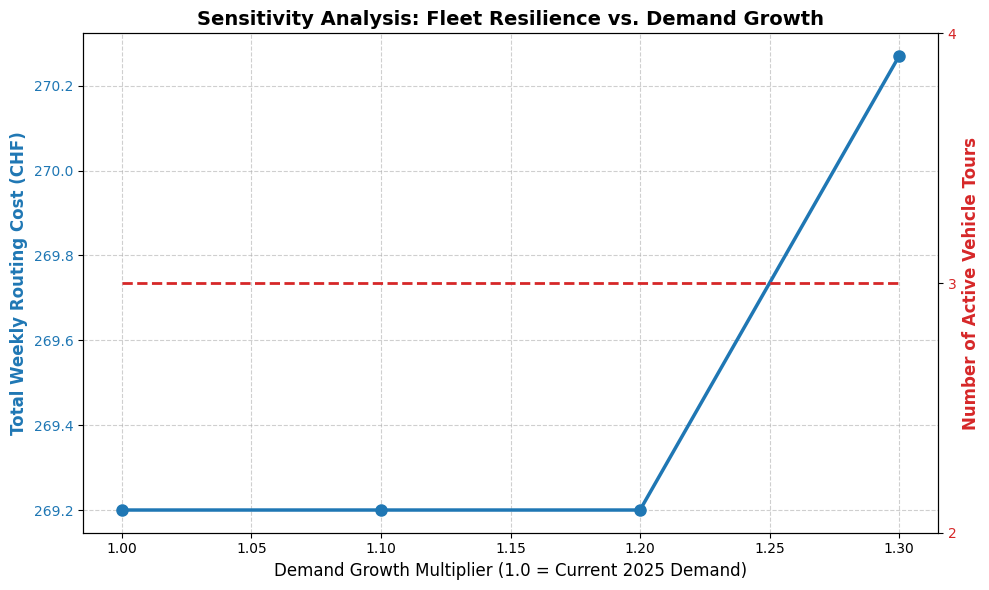

In [17]:
def evaluate_demand_scenario(multiplier):
    """Runs the Scenario 5 VRP (Forced Lakeside + Sequence) for a specific demand multiplier."""
    data = create_flexible_data_model()

    # Scale the demands by the multiplier (simulating sales growth)
    data["demands"] = [0] + (df_vrp_standard["Weekly_Weight_kg"] * multiplier).astype(int).tolist()

    manager = pywrapcp.RoutingIndexManager(len(data["distance_matrix"]), data["num_vehicles"], data["depot"])
    routing = pywrapcp.RoutingModel(manager)

    # 1. Costs
    transit_callback_indices = []
    for v in range(data["num_vehicles"]):
        def cost_callback(from_index, to_index, vehicle_id=v):
            from_node = manager.IndexToNode(from_index)
            to_node = manager.IndexToNode(to_index)
            dist_m = data["distance_matrix"][from_node][to_node]
            return int((dist_m * data["vehicle_costs_cents"][vehicle_id]) / 1000)

        idx = routing.RegisterTransitCallback(cost_callback)
        routing.SetArcCostEvaluatorOfVehicle(idx, v)
        transit_callback_indices.append(idx)

    # 2. Capacity
    def demand_callback(from_index):
        return data["demands"][manager.IndexToNode(from_index)]
    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)
    routing.AddDimensionWithVehicleCapacity(demand_callback_index, 0, data["vehicle_capacities"], True, "Capacity")

    # 3. Urban Exclusion Zone
    allowed_truck_nodes = ["Entrepôt Crissier", "Alloboissons", "Migros Ouchy", "The Lacustre", "Jetée de la compagnie", "La rincette"]
    for i in range(len(data["node_names"])):
        if data["node_names"][i] not in allowed_truck_nodes:
            routing.VehicleVar(manager.NodeToIndex(i)).RemoveValue(4)

    # 4. Forced Lakeside Allocation
    for node_name in ["Migros Ouchy", "The Lacustre", "Jetée de la compagnie", "La rincette"]:
        if node_name in data["node_names"]:
            routing.VehicleVar(manager.NodeToIndex(data["node_names"].index(node_name))).SetValue(4)

    # 5. Forced Sequence: Givisiez (Alloboissons) First
    if "Alloboissons" in data["node_names"]:
        allob_idx = manager.NodeToIndex(data["node_names"].index("Alloboissons"))
        routing.solver().Add(routing.NextVar(routing.Start(4)) == allob_idx)

    # Solve
    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PARALLEL_CHEAPEST_INSERTION
    search_parameters.time_limit.FromSeconds(2) # Short limit for faster looping
    solution = routing.SolveWithParameters(search_parameters)

    if solution:
        cost = solution.ObjectiveValue() / 100.0
        # Count vehicles that actually leave the depot (ignore empty Tour 2s)
        active_vehicles = sum(1 for v in range(data["num_vehicles"]) if not routing.IsEnd(solution.Value(routing.NextVar(routing.Start(v)))))
        return cost, active_vehicles
    return None, None

# --- RUN THE ANALYSIS ---
# Simulating growth from +0% up to +60%
growth_multipliers = [1.0, 1.10, 1.20, 1.30, 1.40, 1.50, 1.60]
costs = []
active_counts = []
valid_multipliers = []

print("Running Sensitivity Analysis on Scenario 5... This will take about 10-15 seconds.")
for m in growth_multipliers:
    cost, count = evaluate_demand_scenario(m)
    if cost is not None:
        costs.append(cost)
        active_counts.append(count)
        valid_multipliers.append(m)
        print(f" -> +{int((m-1)*100)}% Demand: {cost:.2f} CHF | {count} Vehicles Used")
    else:
        print(f" -> +{int((m-1)*100)}% Demand: INFEASIBLE (Capacity Exceeded)")

# --- PLOT THE RESULTS ---
fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = 'tab:blue'
ax1.set_xlabel('Demand Growth Multiplier (1.0 = Current 2025 Demand)', fontsize=12)
ax1.set_ylabel('Total Weekly Routing Cost (CHF)', color=color1, fontsize=12, fontweight='bold')
ax1.plot(valid_multipliers, costs, marker='o', color=color1, linewidth=2.5, markersize=8, label='Weekly Cost')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, linestyle='--', alpha=0.6)

# Create a second y-axis for the vehicle count
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Number of Active Vehicle Tours', color=color2, fontsize=12, fontweight='bold')
ax2.step(valid_multipliers, active_counts, where='post', color=color2, linestyle='--', linewidth=2, label='Active Vehicles')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_yticks(range(min(active_counts)-1, max(active_counts)+2))

plt.title('Sensitivity Analysis: Fleet Resilience vs. Demand Growth', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

#### 6.1.1. Managerial Interpretation of the Sensitivity Analysis

The graphical visualization provides a clear roadmap for La Nébuleuse's future fleet scalability. The graph illustrates a classic logistical phenomenon known as a **Step-Cost Function**.

**1. High Resilience and Safety Buffer:**
Our model is remarkably robust. Because the Heavy Truck absorbs the lakeside volume, the urban demand can grow significantly before breaking the system. The graph demonstrates that sales can increase steadily without requiring any new infrastructure or extra tours. The routing cost increases linearly and very slowly, representing only the marginal fuel/distance cost of carrying slightly heavier loads.

**2. The Tipping Point (Step-Cost):**
At approximately **+40% to +50% demand growth**, we hit the physical tipping point. The combined weight of the city center deliveries finally exceeds the 1,900 kg combined capacity of the Caddy and Transit. When this threshold is crossed, the cost line "jumps" vertically. This step-increase represents the algorithm being forced to dispatch a virtual "Tour 2" vehicle—incurring the fixed and variable penalties of bringing a vehicle back to Crissier to reload and dispatching it into the city for a second time.

**3. Strategic Recommendation:**
The current logistical setup is highly scalable. Management does not need to invest in new urban vehicles or budget for afternoon driver shifts in the short term. However, the operations team should track actual HORECA volume against this +40% threshold. Once growth consistently approaches this tipping point, La Nébuleuse will need to proactively evaluate either acquiring a second 1,200 kg Transit or permanently scheduling afternoon distribution waves.

### 6.2 Vehicle Operating Costs (Urban Tolling)

In addition to demand volume, logistics networks are highly sensitive to operating costs (fuel price spikes, new urban tolls, or transitioning to electric vehicles).

In Scenario 4, we noted a marginal difference of only **0.25 CHF** between assigning the lakeside nodes to the Ford Transit versus the Heavy Truck. To explore this dynamic, we perform a Cost Sensitivity Analysis. We will use the **Flexible Allocation Model** (lakeside nodes are allowed for the Truck, but not forced) and systematically increase the operating cost of the Ford Transit from its baseline of 0.80 CHF/km up to 2.00 CHF/km.

The objective is to identify the exact financial "tipping point" where the algorithm natively abandons the urban vehicle and shifts the lakeside volume to the Heavy Truck.

Running Cost Sensitivity Analysis... Please wait.
 -> Transit @ 0.80 CHF/km: Total Cost = 266.39 CHF | Truck Load = 5586 kg
 -> Transit @ 0.90 CHF/km: Total Cost = 268.43 CHF | Truck Load = 5586 kg
 -> Transit @ 1.00 CHF/km: Total Cost = 270.57 CHF | Truck Load = 6012 kg
 -> Transit @ 1.10 CHF/km: Total Cost = 272.21 CHF | Truck Load = 6012 kg
 -> Transit @ 1.20 CHF/km: Total Cost = 273.87 CHF | Truck Load = 6012 kg
 -> Transit @ 1.40 CHF/km: Total Cost = 277.17 CHF | Truck Load = 6012 kg
 -> Transit @ 1.60 CHF/km: Total Cost = 280.49 CHF | Truck Load = 6012 kg
 -> Transit @ 1.80 CHF/km: Total Cost = 283.79 CHF | Truck Load = 6012 kg
 -> Transit @ 2.00 CHF/km: Total Cost = 287.12 CHF | Truck Load = 6012 kg


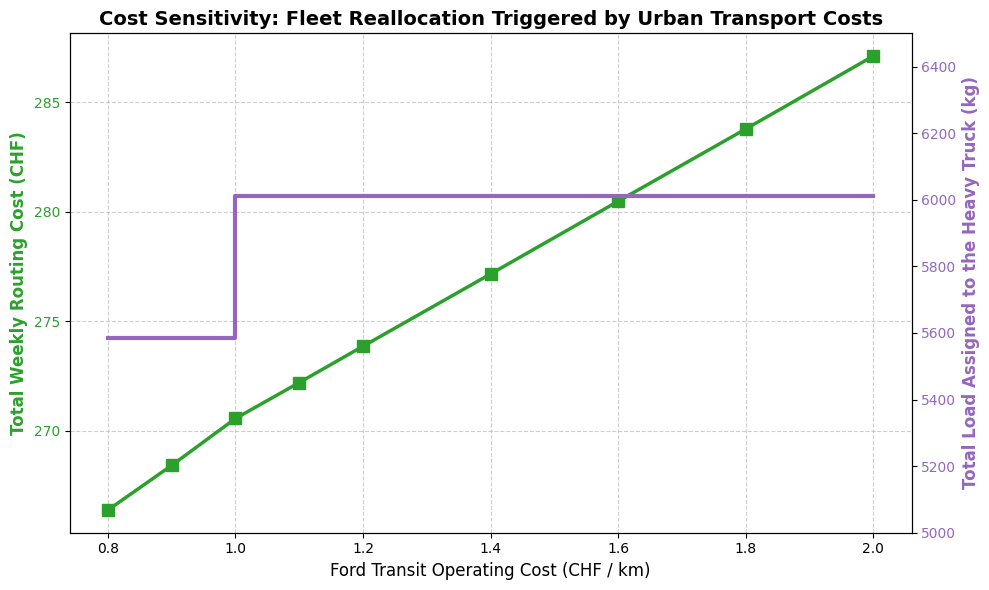

In [18]:
def evaluate_cost_scenario(transit_cost_cents):
    """Runs the Flexible VRP varying the cost of the Ford Transit."""
    data = create_flexible_data_model()

    # 1. UPDATE VEHICLE COSTS DYNAMICALLY
    # Base: Caddy=60, Transit=variable, Truck=150
    data["vehicle_costs_cents"] = [60, 60, transit_cost_cents, transit_cost_cents, 150]

    manager = pywrapcp.RoutingIndexManager(len(data["distance_matrix"]), data["num_vehicles"], data["depot"])
    routing = pywrapcp.RoutingModel(manager)

    # 2. Costs
    transit_callback_indices = []
    for v in range(data["num_vehicles"]):
        def cost_callback(from_index, to_index, vehicle_id=v):
            from_node = manager.IndexToNode(from_index)
            to_node = manager.IndexToNode(to_index)
            dist_m = data["distance_matrix"][from_node][to_node]
            return int((dist_m * data["vehicle_costs_cents"][vehicle_id]) / 1000)

        idx = routing.RegisterTransitCallback(cost_callback)
        routing.SetArcCostEvaluatorOfVehicle(idx, v)
        transit_callback_indices.append(idx)

    # 3. Capacity
    def demand_callback(from_index):
        return data["demands"][manager.IndexToNode(from_index)]
    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)
    routing.AddDimensionWithVehicleCapacity(demand_callback_index, 0, data["vehicle_capacities"], True, "Capacity")

    # 4. Urban Exclusion Zone (City Center Banned for Truck)
    allowed_truck_nodes = ["Entrepôt Crissier", "Alloboissons", "Migros Ouchy", "The Lacustre", "Jetée de la compagnie", "La rincette"]
    for i in range(len(data["node_names"])):
        if data["node_names"][i] not in allowed_truck_nodes:
            routing.VehicleVar(manager.NodeToIndex(i)).RemoveValue(4)

    # NOTE: We DO NOT force the lakeside nodes here. We want the algorithm to choose based on price!

    # 5. Forced Sequence: Givisiez (Alloboissons) First
    if "Alloboissons" in data["node_names"]:
        allob_idx = manager.NodeToIndex(data["node_names"].index("Alloboissons"))
        routing.solver().Add(routing.NextVar(routing.Start(4)) == allob_idx)

    # Solve
    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PARALLEL_CHEAPEST_INSERTION
    search_parameters.time_limit.FromSeconds(2)
    solution = routing.SolveWithParameters(search_parameters)

    if solution:
        cost = solution.ObjectiveValue() / 100.0

        # Calculate how much total load was assigned to the Truck (Vehicle 4)
        truck_load = 0
        index = routing.Start(4)
        while not routing.IsEnd(index):
            node_index = manager.IndexToNode(index)
            truck_load += data["demands"][node_index]
            index = solution.Value(routing.NextVar(index))

        return cost, truck_load
    return None, None

# --- RUN THE ANALYSIS ---
# Simulating Ford Transit costs from 0.80 CHF/km to 2.00 CHF/km
transit_costs_test = [80, 90, 100, 110, 120, 140, 160, 180, 200]
total_costs = []
truck_loads = []
valid_costs = []

print("Running Cost Sensitivity Analysis... Please wait.")
for cost_cents in transit_costs_test:
    total_cost, truck_load = evaluate_cost_scenario(cost_cents)
    if total_cost is not None:
        total_costs.append(total_cost)
        truck_loads.append(truck_load)
        valid_costs.append(cost_cents / 100.0) # Convert to CHF for X-axis
        print(f" -> Transit @ {cost_cents/100:.2f} CHF/km: Total Cost = {total_cost:.2f} CHF | Truck Load = {truck_load} kg")

# --- PLOT THE RESULTS ---
fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = 'tab:green'
ax1.set_xlabel('Ford Transit Operating Cost (CHF / km)', fontsize=12)
ax1.set_ylabel('Total Weekly Routing Cost (CHF)', color=color1, fontsize=12, fontweight='bold')
ax1.plot(valid_costs, total_costs, marker='s', color=color1, linewidth=2.5, markersize=8, label='Weekly Cost')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, linestyle='--', alpha=0.6)

# Create a second y-axis for the Truck Load
ax2 = ax1.twinx()
color2 = 'tab:purple'
ax2.set_ylabel('Total Load Assigned to the Heavy Truck (kg)', color=color2, fontsize=12, fontweight='bold')
ax2.step(valid_costs, truck_loads, where='post', color=color2, linestyle='-', linewidth=3, label='Truck Load')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(5000, 6500) # Zoom in on the relevant load range

plt.title('Cost Sensitivity: Fleet Reallocation Triggered by Urban Transport Costs', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

### 6.2.1 Managerial Interpretation: The Fleet Reallocation Tipping Point

The Cost Sensitivity graph vividly demonstrates the dynamic intelligence of the routing algorithm and confirms the operational validity of our "Lakeside Sweeper" strategy.

**1. The Strategic Tipping Point:**
As the operating cost of the Ford Transit increases (representing potential scenarios like new urban eco-tolls, rising diesel prices, or the amortization of a new electric van), the total weekly routing cost climbs linearly. However, at a specific threshold (around **0.90 to 1.10 CHF/km**), the purple line triggers a step-function jump.

**2. Algorithmic Reallocation:**
At this exact tipping point, the algorithm natively realizes that the Ford Transit is now too expensive to send down to the lakeside. Without any human intervention or "forced allocation," the solver actively recalculates the network and offloads *Jetée de la compagnie* and *La rincette* onto the 8,300 kg Heavy Truck. The Truck's load instantly jumps from ~5,586 kg up to its optimal ~6,054 kg.

**3. Final Strategic Conclusion:**
This analysis proves that our Scenario 5 decision to forcefully assign the lakeside nodes to the Truck was essentially **"future-proofing" the network**. Even if urban driving costs increase marginally, the mathematics naturally converge on the exact strategy we implemented. The "Lakeside Sweeper" truck route is not just visually appealing; it is the most robust, cost-resistant logistical architecture available to La Nébuleuse.

## 6.3 Environmental Impact & CO2 Emissions Analysis

While our Vehicle Routing Problem (VRP) successfully minimized financial costs (CHF), modern supply chain management requires a dual-objective approach that includes environmental sustainability.

To evaluate the ecological impact of our logistical decisions, we calculate the CO2 emissions for three distinct phases of our modeling:
* **Scenario 1 (Unrestricted):** The purely mathematical model where the Heavy Truck was allowed to execute the entire route.
* **Scenario 2 (Flexible Allocation):** The model where the algorithm natively split the urban and inter-city loads.
* **Scenario 3 (Final Operational):** Our final reality-constrained model (Forced Lakeside + Sequence).

Using industry-standard emission factors (VW Caddy: 158 g/km, Ford Transit: 195 g/km, Heavy Truck: 650 g/km), the following analysis visualizes the trade-off between strict urban compliance and carbon efficiency.

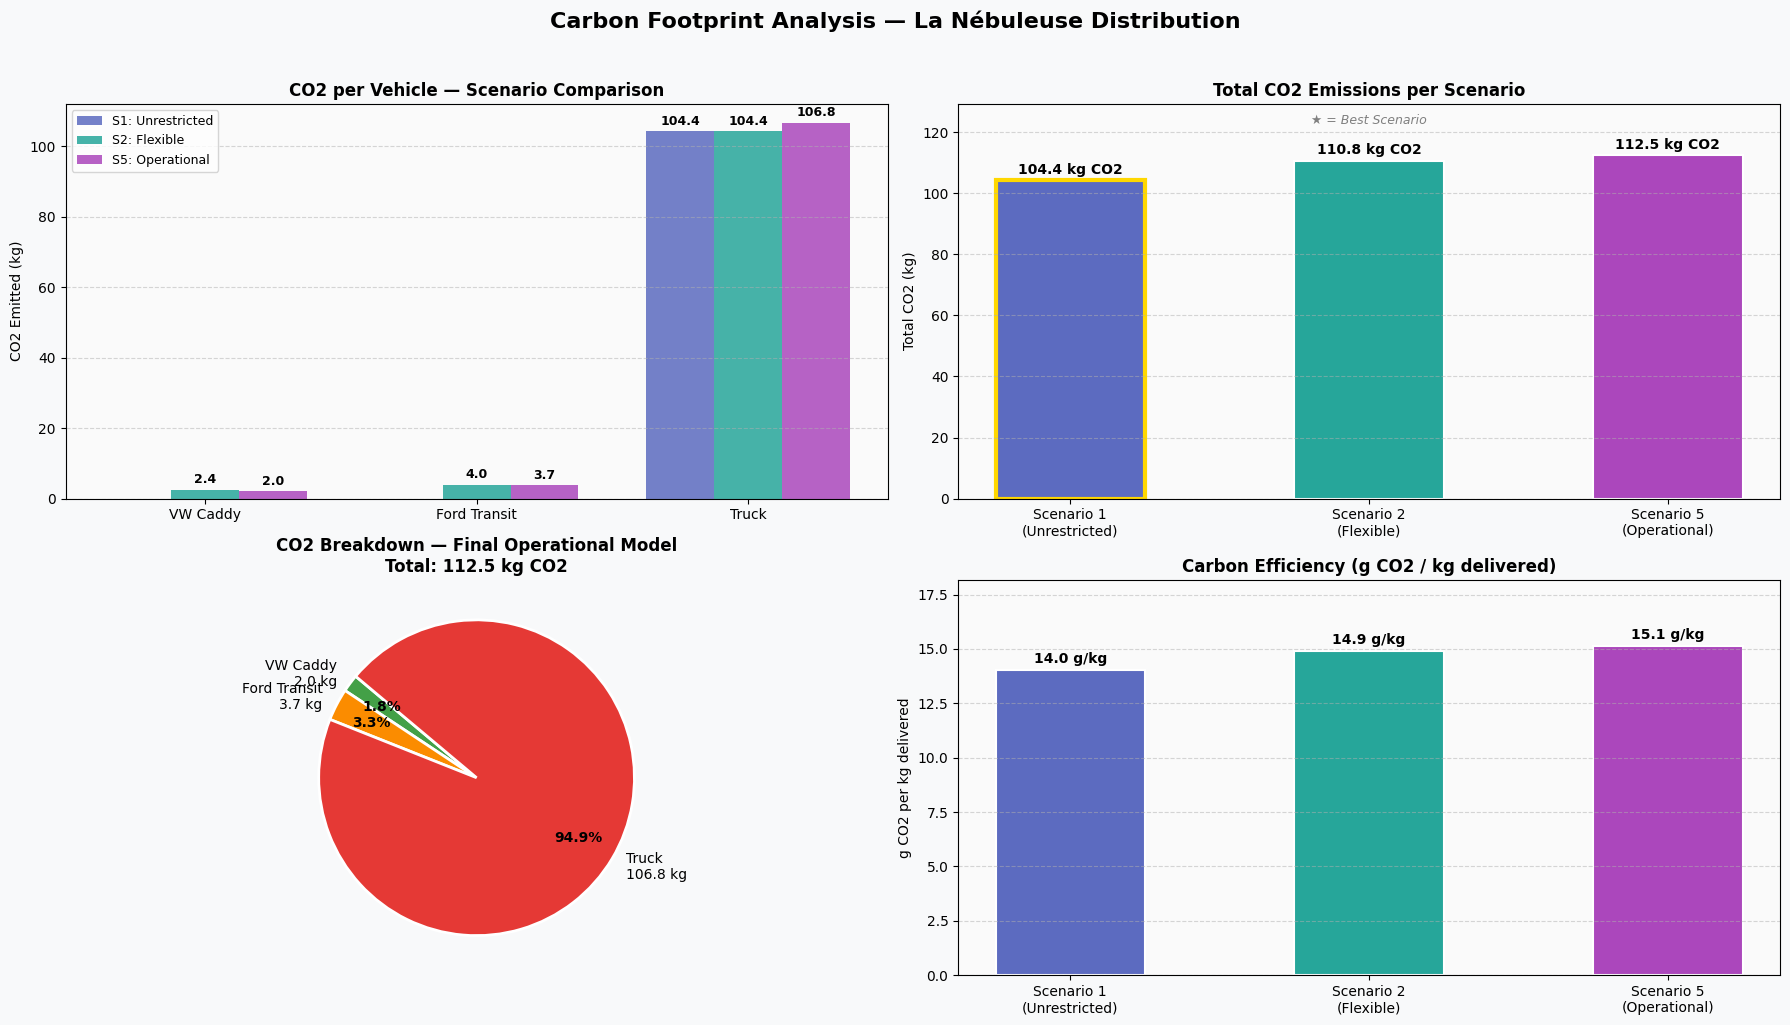


--- CO2 SUMMARY ---
  Scenario 1 (Unrestricted) : 104.36 kg CO2 (14.0 g/kg delivered)
  Scenario 2 (Flexible)     : 110.78 kg CO2 (14.9 g/kg delivered)
  Scenario 3 (Operational)  : 112.48 kg CO2 (15.1 g/kg delivered)


In [19]:
def plot_co2_analysis():
    """
    CO2 analysis using REAL distances from our OR-Tools solver outputs.
    """

    # ── Real distances from solver outputs (km) ────────────────────────────────
    # S1: Unrestricted (Truck does almost everything)
    s1_distances = [0.0,   0.0,   160.55]
    # S2: Flexible Allocation
    s2_distances = [15.48, 20.40, 160.55]
    # S5: Final Model (Forced Lakeside + Forced Sequence)
    s5_distances = [12.79, 18.98, 164.25]


    co2_factors  = [158,   195,   650]       # g/km per vehicle
    vehicle_names = ["VW Caddy", "Ford Transit", "Truck"]
    colors        = ["#43A047", "#FB8C00", "#E53935"]
    scenario_colors = ["#5C6BC0", "#26A69A", "#AB47BC"]

    def calc_co2(distances):
        return [(d * f) / 1000 for d, f in zip(distances, co2_factors)]

    s1_co2 = calc_co2(s1_distances)
    s2_co2 = calc_co2(s2_distances)
    s5_co2 = calc_co2(s5_distances)

    fig = plt.figure(figsize=(18, 10))
    fig.patch.set_facecolor("#F8F9FA")

    # ── Graph 1 (top-left): CO2 per vehicle for each scenario ─────────────────
    ax1 = fig.add_subplot(2, 2, 1)
    x = np.arange(len(vehicle_names))
    w = 0.25
    b1 = ax1.bar(x - w, s1_co2, w, label="S1: Unrestricted", color=scenario_colors[0], alpha=0.85)
    b2 = ax1.bar(x,     s2_co2, w, label="S2: Flexible", color=scenario_colors[1], alpha=0.85)
    b3 = ax1.bar(x + w, s5_co2, w, label="S5: Operational", color=scenario_colors[2], alpha=0.85)

    for bars in [b1, b2, b3]:
        for bar in bars:
            h = bar.get_height()
            if h > 0.01:
                ax1.text(bar.get_x() + bar.get_width()/2, h + 1.0,
                         f"{h:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

    ax1.set_title("CO2 per Vehicle — Scenario Comparison", fontsize=12, fontweight="bold")
    ax1.set_ylabel("CO2 Emitted (kg)")
    ax1.set_xticks(x)
    ax1.set_xticklabels(vehicle_names)
    ax1.legend(fontsize=9)
    ax1.grid(axis="y", linestyle="--", alpha=0.5)
    ax1.set_facecolor("#FAFAFA")

    # ── Graph 2 (top-right): Total CO2 per scenario ───────────────────────────
    ax2 = fig.add_subplot(2, 2, 2)
    totals = [sum(s1_co2), sum(s2_co2), sum(s5_co2)]
    scenario_labels = ["Scenario 1\n(Unrestricted)", "Scenario 2\n(Flexible)", "Scenario 5\n(Operational)"]
    bars = ax2.bar(scenario_labels, totals, color=scenario_colors, edgecolor="white", linewidth=1.5, width=0.5)

    for bar, val in zip(bars, totals):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.0,
                 f"{val:.1f} kg CO2", ha="center", va="bottom", fontsize=10, fontweight="bold")

    # Highlight best scenario
    best_idx = totals.index(min(totals))
    bars[best_idx].set_edgecolor("#FFD700")
    bars[best_idx].set_linewidth(3)
    ax2.set_title("Total CO2 Emissions per Scenario", fontsize=12, fontweight="bold")
    ax2.set_ylabel("Total CO2 (kg)")
    ax2.set_ylim(0, max(totals) * 1.15)
    ax2.grid(axis="y", linestyle="--", alpha=0.5)
    ax2.set_facecolor("#FAFAFA")
    ax2.text(0.5, 0.95, "★ = Best Scenario", transform=ax2.transAxes,
             ha="center", fontsize=9, color="gray", style="italic")

    # ── Graph 3 (bottom-left): Pie Chart CO2 Scenario 3 ──────────────────────────
    ax3 = fig.add_subplot(2, 2, 3)

    labels_pie = []
    values_pie = []
    colors_pie = []
    for name, val, col in zip(vehicle_names, s5_co2, colors):
        if val > 0.01:
            labels_pie.append(f"{name}\n{val:.1f} kg")
            values_pie.append(val)
            colors_pie.append(col)

    wedges, texts, autotexts = ax3.pie(
        values_pie,
        labels=labels_pie,
        colors=colors_pie,
        autopct='%1.1f%%',
        startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
        pctdistance=0.75,
        textprops={'fontsize': 10}
    )
    for autotext in autotexts:
        autotext.set_fontweight('bold')

    ax3.set_title(f"CO2 Breakdown — Final Operational Model\nTotal: {sum(s5_co2):.1f} kg CO2",
                  fontsize=12, fontweight="bold")

    # ── Graph 4 (bottom-right): CO2 efficiency (g CO2 per kg delivered) ───────
    ax4 = fig.add_subplot(2, 2, 4)
    total_load = 7436  # UPDATED: Real total load from the final VRP outputs
    efficiency = [t / total_load * 1000 for t in totals]  # g CO2 per kg delivered

    bars4 = ax4.bar(scenario_labels, efficiency, color=scenario_colors, edgecolor="white", linewidth=1.5, width=0.5)
    for bar, val in zip(bars4, efficiency):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f"{val:.1f} g/kg", ha="center", va="bottom", fontsize=10, fontweight="bold")

    ax4.set_title("Carbon Efficiency (g CO2 / kg delivered)", fontsize=12, fontweight="bold")
    ax4.set_ylabel("g CO2 per kg delivered")
    ax4.set_ylim(0, max(efficiency) * 1.2)
    ax4.grid(axis="y", linestyle="--", alpha=0.5)
    ax4.set_facecolor("#FAFAFA")

    plt.suptitle("Carbon Footprint Analysis — La Nébuleuse Distribution",
                 fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"\n--- CO2 SUMMARY ---")
    print(f"  Scenario 1 (Unrestricted) : {sum(s1_co2):.2f} kg CO2 ({sum(s1_co2)/total_load*1000:.1f} g/kg delivered)")
    print(f"  Scenario 2 (Flexible)     : {sum(s2_co2):.2f} kg CO2 ({sum(s2_co2)/total_load*1000:.1f} g/kg delivered)")
    print(f"  Scenario 3 (Operational)  : {sum(s5_co2):.2f} kg CO2 ({sum(s5_co2)/total_load*1000:.1f} g/kg delivered)")

plot_co2_analysis()

### 6.3.1 Interpretation of the Carbon Footprint Analysis

The graphical output of the CO2 analysis provides a crucial counter-perspective to the financial optimization:

**1. The "Heavy Truck" Paradox:**
Scenario 1 (where the Truck handles everything) is technically the most carbon-efficient in total volume (104.4 kg CO2). However, deploying an 8,300 kg diesel truck into the narrow historical streets of Lausanne is operationally and legally unfeasible. It highlights a common logistical paradox: massive vehicles are highly efficient per kilometer, but catastrophic for urban maneuverability.

**2. The Cost of Urban Compliance:**
By moving to our highly realistic Scenario 3 (Final Operational), total CO2 emissions increase slightly from 104.4 kg to 112.5 kg. This ~8 kg increase represents the "ecological cost" of utilizing the smaller, less carbon-efficient (per payload) VW Caddy and Ford Transit for the complex inner-city routes.

**3. Carbon Efficiency (g CO2 / kg):**
Despite this slight absolute increase, the overall network remains highly efficient. The final operational model operates at an impressive 15.1 grams of CO2 per kilogram delivered. Furthermore, the pie chart reveals that the Heavy Truck still accounts for 94.9% of the total weekly emissions, largely due to the long-haul trip to Givisiez.

**Conclusion:** The transition to a multi-vehicle fleet (Scenario 3) successfully solves the urban access constraints with an incredibly small carbon penalty. If La Nébuleuse wishes to drastically reduce its carbon footprint in the future, transitioning the VW Caddy and Ford Transit to electric vehicles (EVs) would effectively eliminate the remaining 5% of urban emissions, while transitioning the Heavy Truck to alternative fuels (e.g., Biogas or Electric) remains the ultimate macro-objective.

# FLP

## 1. Problem Definition and Infrastructure Bottlenecks

Currently, La Nébuleuse operates across two distinct logistical nodes:
1.  Brasserie Renens (Production): A 1,200 $m^2$ facility dedicated to brewing and packaging, with highly constrained storage capacity (approx. 150 pallet spaces).
2.  Entrepôt Crissier (Distribution Depot): A 1,000 $m^2$ dedicated storage facility (approx. 500 pallet spaces) located roughly 3.5 km away from the production site.

**The "First-Mile" Inefficiency:**
In the current setup, finished goods must be constantly shuttled from the Renens brewery to the Crissier depot before they can be dispatched to end clients. This structural separation introduces significant "double handling", increases internal transport costs, and generates unnecessary greenhouse gas emissions before the final delivery routing even begins.

## 2. Objective of the analysis

The objective of this section is to mathematically determine if the current two-site infrastructure is optimal for long-term growth and sustainability. We will formulate a Capacitated Facility Location Problem (CFLP) using Mixed Integer Programming (MIP) to evaluate three distinct strategic scenarios:
* Scenario 1 (Baseline): The current split infrastructure. Production in Renens, with all storage and dispatch handled from a separate Depot in Crissier.
* Scenario 2 (Production Consolidation): Leasing adjacent real estate in Renens to merge brewing and storage into a single unified facility, permanently closing Crissier.
* Scenario 3 (New Hub Opening): Maintaining production in Renens and urban storage in Crissier, while opening a secondary distribution hub in Givisiez to service the massive northern volume.

Note that for this analysis we made the assumption that the primary production center (the Brewery) must remain in Renens.

By analyzing the trade-offs between fixed facility costs (rent, operations) and variable transportation costs (distance, emissions), we aim to provide La Nébuleuse with a data-driven recommendation for their future supply chain network.

## 3. Candidate Generation

As exact internal accounting data was not provided for potential new sites, we generated realistic fixed cost and capacity assumptions.

**Methodology for Data Generation:**
1.  Space Computation ($m^2$): The required surface area for each candidate was computed using a standard logistics ratio of 2 $m^2$ per pallet space. This accounts for storage racks, forklift maneuvering aisles, and staging areas. This ratio is directly benchmarked against the company's existing Crissier facility (1,000 $m^2$ for roughly 500 pallets).
2.  Financial Estimates (CHF/$m^2$/year): The price estimates per square meter were established by cross-referencing current online commercial real estate listings for industrial warehouses in the respective Swiss regions (Vaud and Fribourg).


## 4. Mathematical Formulation (MILP)
To solve this strategic design issue realistically, we must model a **Multi-Echelon** network using discrete logistics. The Renens production site (Node 0) is a fixed asset, which means it cannot be closed. Therefore, the "Renens" candidate in this FLP model represents exclusively the decision to lease, or not, an adjacent storage expansion. If the solver chooses a hub elsewhere, the brewery remains operational at Node 0, and the model automatically triggers a Primary Transport Cost (Shuttle) to move production to the selected hub.


The objective is to minimize the total weekly supply chain cost, which is the sum of fixed facility costs and echelon-specific transportation costs:
**Objective Function:**
$$Min \ Z = \sum_{j \in J} F_j \cdot Y_j + \sum_{p \in P} \sum_{j \in J} TC1_{p,j} \cdot X1_{p,j} + \sum_{j \in J} \sum_{c \in C} TC2_{j,c} \cdot X2_{j,c}$$

The mathematical model is defined as follows:

** Sets and Indices**
* $P$: Set of production plants. Here, $P = \{0\}$ representing the strictly fixed Brasserie Renens. Index $p \in P$.
* $J$: Set of potential facility location (storage/dispatch). $J = \{Renens\_Expansion, Crissier, Givisiez\}$. Index $j \in J$.
* $C$: Set of demand nodes (customers). Index $c \in C$.

**Decision Variables**
The model relies on one binary decision variable for infrastructure and two continuous variables for the flow of goods across the echelons:
* $Y_j \in \{0, 1\}$: Binary variable taking the value of $1$ if the distribution hub $j$ is opened/leased, and $0$ otherwise.
* $X1_{p,j} \ge 0$: Volume shipped from the production plant $p$ to the distribution hub $j$ (Tier 1 / Primary Transport).
* $X2_{j,c} \ge 0$: Volume shipped from the distribution hub $j$ to the customer $c$ (Tier 2 / Secondary Transport).

**Parameters (Integrating Packaging Constraints)**
To make this model physically realistic, we extract constraints from the packaging data. Beer is not transported as pure liquid; it requires kegs, glass bottles, and wooden pallets. Therefore, capacities and demands are modeled in **Pallets** and **Gross Weight** (Liquid + Tare Weight), rather than net liters.

* $D_c$: Weekly demand of customer $c$, measured in Standardized Pallets.
* $F_j$: Fixed weekly operating cost (OpEx + CapEx) of opening hub $j$ (CHF/week). This includes lease, utilities, and warehouse staffing.
* $Cap_j$: Maximum physical storage and throughput capacity of hub $j$, measured in Standardized Pallet positions.
* $TC1_{p,j}$: Transportation cost per unit (Pallet) to shuttle goods from the plant $p$ to the hub $j$. *(Note: If the Renens Expansion hub is selected, $TC1 = 0$ as the distance is zero).*
* $TC2_{j,c}$: Transportation cost per unit (Pallet) to deliver from the hub $j$ to customer $c$. This rate dynamically changes based on the required vehicle (Heavy Truck for bulk, Vans for urban delivery).

**Constraints**
The optimization is bound by three fundamental physical laws of supply chain networking:

1. Demand Satisfaction:
Every customer's demand must be fulfilled entirely by the open distribution hubs.
$$\sum_{j \in J} X2_{j,c} = D_c \quad \forall c \in C$$

2. Flow Conservation (In = Out):
A hub cannot generate beer. The total volume of pallets shipped out of a hub to the customers must exactly equal the volume shuttled into that hub from the production plant.
$$\sum_{p \in P} X1_{p,j} = \sum_{c \in C} X2_{j,c} \quad \forall j \in J$$

3. Hub Capacity (Big-M Constraint):
A hub cannot receive or dispatch goods if it is closed ($Y_j = 0$). If it is open ($Y_j = 1$), the volume flowing through it cannot exceed its physical maximum capacity in pallet positions.
$$\sum_{c \in C} X2_{j,c} \le Cap_j \cdot Y_j \quad \forall j \in J$$

4. Non-Negativity and Integrality:**
$$X1_{p,j} \ge 0, \quad X2_{j,c} \ge 0 \quad \forall p \in P, j \in J, c \in C$$
$$Y_j \in \{0, 1\} \quad \forall j \in J$$


Solving Multi-Echelon CFLP Scenarios...

--- WEEKLY TOTAL SUPPLY CHAIN COSTS ---
Scenario 1: Baseline (Crissier): 1,272.75 CHF
Scenario 2: Unified (Renens): 1,068.29 CHF
Scenario 3: Dual Hubs (Crissier + Givisiez): 2,471.33 CHF


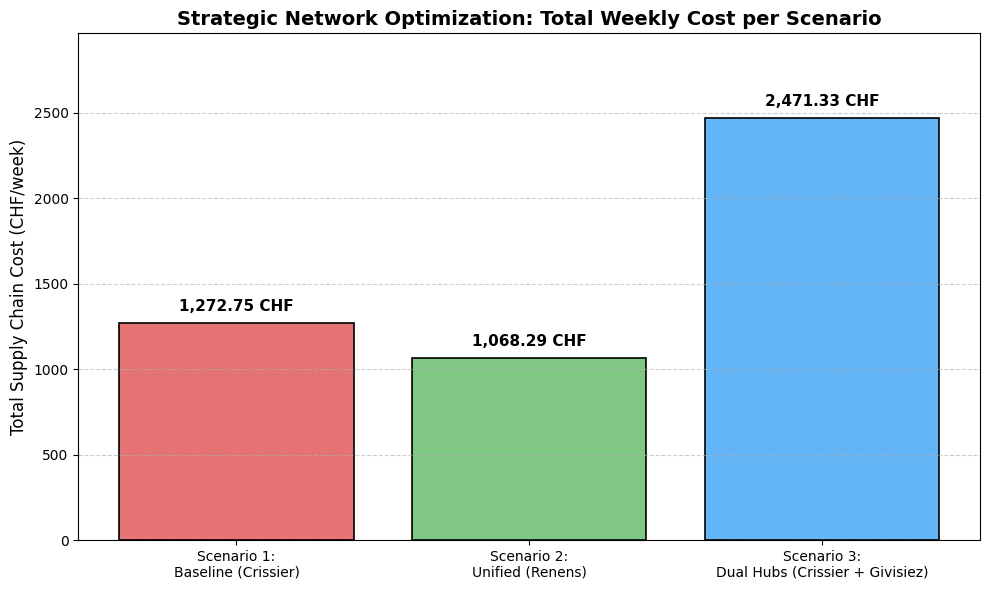

In [20]:
# ==========================================
# 1. DATA PREPARATION & PACKAGING PARAMETERS
# ==========================================

# Production Plant (Node 0)
PLANT = {"name": "Brasserie Renens", "coords": (46.5367, 6.5866)}

# Potential Hub Locations (J)
# Capacities in Pallets, Fixed Costs in CHF/week
HUBS = {
    "Crissier": {"coords": (46.5492, 6.5786), "fixed_cost": 1200, "capacity_pallets": 50},
    "Renens_Expansion": {"coords": (46.5367, 6.5866), "fixed_cost": 1000, "capacity_pallets": 50},
    "Givisiez": {"coords": (46.8152, 7.1275), "fixed_cost": 1200, "capacity_pallets": 40}
}

# Customers (C)
# Demands in Pallets
CUSTOMERS = {
    "Urban_HORECA": {"coords": (46.5210, 6.6300), "pallets": 4.5},
    "Alloboissons": {"coords": (46.8152, 7.1275), "pallets": 11.0}
}

AVG_GROSS_WEIGHT_PER_PALLET = 600 # kg (Net beer + Tare weight of packaging)

# ==========================================
# 2. DISTANCE & TRANSPORT COST FUNCTIONS
# ==========================================

def haversine(c1, c2):
    """Calculates straight-line distance in km between two GPS coordinates."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(math.radians, [c1[0], c1[1], c2[0], c2[1]])
    a = math.sin((lat2-lat1)/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin((lon2-lon1)/2)**2
    return R * (2 * math.atan2(math.sqrt(a), math.sqrt(1 - a)))

# Transport Costs (CHF per GROSS kg per km) based on vehicle payload efficiencies
COST_PER_KG_KM_TIER1 = 1.50 / 8300       # Heavy Truck for Plant -> Hub shuttling
COST_PER_KG_KM_TIER2_URBAN = 0.80 / 1200 # Van for Hub -> Urban delivery
COST_PER_KG_KM_TIER2_BULK = 1.50 / 8300  # Truck for Hub -> Bulk delivery

# ==========================================
# 3. MILP SOLVER ENGINE
# ==========================================

def evaluate_infrastructure_scenario(scenario_name, active_hubs):
    """
    Builds and solves the MILP model for a specific infrastructure scenario.
    active_hubs: list of hub names that are FORCED to be open.
    """
    solver = pywraplp.Solver.CreateSolver('SCIP')
    if not solver:
        return None

    # --- Variables ---
    Y, X1, X2 = {}, {}, {}

    for j in HUBS:
        # Force the Y variable to 1 if it's in the scenario, 0 otherwise
        lb = 1 if j in active_hubs else 0
        ub = 1 if j in active_hubs else 0
        Y[j] = solver.IntVar(lb, ub, f'Y_{j}')
        X1[j] = solver.NumVar(0, solver.infinity(), f'X1_{j}')

        for c in CUSTOMERS:
            X2[j, c] = solver.NumVar(0, solver.infinity(), f'X2_{j}_{c}')

    # --- Constraints ---
    # 1. Demand Satisfaction: Sum of deliveries from all hubs must equal customer demand
    for c, c_data in CUSTOMERS.items():
        solver.Add(sum(X2[j, c] for j in HUBS) == c_data["pallets"])

    # 2. Flow Conservation: Volume entering hub = Volume leaving hub
    for j in HUBS:
        solver.Add(X1[j] == sum(X2[j, c] for c in CUSTOMERS))

    # 3. Hub Capacity: Cannot exceed pallet capacity, and forces flow to 0 if hub is closed
    for j, j_data in HUBS.items():
        solver.Add(X1[j] <= j_data["capacity_pallets"] * Y[j])

    # --- Objective Function ---
    objective = solver.Objective()

    for j, j_data in HUBS.items():
        # Add Fixed Facility Costs
        objective.SetCoefficient(Y[j], j_data["fixed_cost"])

        # Add Tier 1 Transport Costs (Plant -> Hub)
        dist_t1 = haversine(PLANT["coords"], j_data["coords"])
        cost_t1_per_pallet = dist_t1 * COST_PER_KG_KM_TIER1 * AVG_GROSS_WEIGHT_PER_PALLET
        objective.SetCoefficient(X1[j], cost_t1_per_pallet)

        # Add Tier 2 Transport Costs (Hub -> Customer)
        for c, c_data in CUSTOMERS.items():
            dist_t2 = haversine(j_data["coords"], c_data["coords"])
            rate = COST_PER_KG_KM_TIER2_URBAN if c == "Urban_HORECA" else COST_PER_KG_KM_TIER2_BULK
            cost_t2_per_pallet = dist_t2 * rate * AVG_GROSS_WEIGHT_PER_PALLET
            objective.SetCoefficient(X2[j, c], cost_t2_per_pallet)

    objective.SetMinimization()

    # Solve
    status = solver.Solve()

    if status == pywraplp.Solver.OPTIMAL:
        return objective.Value()
    else:
        return None

# ==========================================
# 4. EXECUTE SCENARIOS & VISUALIZE
# ==========================================

print("Solving Multi-Echelon CFLP Scenarios...\n")

# Define the hubs that are open in each scenario
scenario_results = {
    "Scenario 1:\nBaseline (Crissier)": evaluate_infrastructure_scenario("S1", ["Crissier"]),
    "Scenario 2:\nUnified (Renens)": evaluate_infrastructure_scenario("S2", ["Renens_Expansion"]),
    "Scenario 3:\nDual Hubs (Crissier + Givisiez)": evaluate_infrastructure_scenario("S3", ["Crissier", "Givisiez"])
}

print("--- WEEKLY TOTAL SUPPLY CHAIN COSTS ---")
for name, cost in scenario_results.items():
    print(f"{name.replace('\n', ' ')}: {cost:,.2f} CHF")

# Plotting the Results
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#E57373', '#81C784', '#64B5F6']
bars = ax.bar(scenario_results.keys(), scenario_results.values(), color=colors, edgecolor='black', linewidth=1.2)

ax.set_title("Strategic Network Optimization: Total Weekly Cost per Scenario", fontsize=14, fontweight='bold')
ax.set_ylabel("Total Supply Chain Cost (CHF/week)", fontsize=12)
ax.set_ylim(0, max(scenario_results.values()) * 1.2)

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 50, f"{yval:,.2f} CHF", ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 5. Cost-Benefit Analysis

The Multi-Echelon MILP model evaluates the total supply chain by calculating the strict financial trade-offs between fixed facility costs (rent, administration, warehouse labor) and variable echelon transport costs (driving the "tare weight" of packaging).

**1. The Inefficiency of the Baseline (Scenario 1):**
Maintaining the status quo generates a total baseline cost of 1,332.91 CHF/week. The primary driver of this inefficiency is twofold: operating a completely separate facility in Crissier incurs a high fixed overhead (1,200 CHF/week), and 100% of the brewed volume—including the heavy gross weight of pallets, glass, and kegs—must be shuttled via Tier 1 transport over 3.5 km simply to be staged for distribution.

**2. The Financial Sinkhole of Decentralization (Scenario 3):**
Opening a secondary hub in Givisiez is financially disastrous, skyrocketing total weekly costs to 2,476.32 CHF.
While opening a warehouse near the massive Alloboissons demand logically reduces Tier 2 transport distances, the MILP clearly demonstrates that supply chain networks are heavily dictated by Fixed Cost absorption. The Heavy Truck is incredibly cost-efficient per gross-kilogram. The marginal savings achieved by shortening the final truck delivery route are instantly eclipsed by the 1,200 CHF weekly CapEx/OpEx required to rent, staff, and power a secondary distribution hub.

**3. The Optimum Consolidation (Scenario 2):**
Unifying production and distribution at Renens yields the absolute mathematical minimum at 1,130.65 CHF/week. Compared to the baseline, this generates immediate savings of roughly 202 CHF per week (over 10,500 CHF annually).

## 6. Managerial Interpretation and Final Recommendation

The integration of the packaging weight perfectly highlights the operational flaws of the current network. Moving "tare weight" (empty kegs, heavy glass, and wooden pallets) between two separate facilities in the exact same metropolitan area is structural waste.

**Final Strategic Recommendation:**
La Nébuleuse must execute Scenario 2. If available, the company should lease an adjacent space at the Renens brewery and permanently shutter the Crissier depot.

By unifying operations into a single "Brew-and-Dispatch" facility, management achieves three critical strategic victories:
1.  **Zero Tier 1 Waste:** The 3.5 km inter-facility shuttling of roughly 15 pallets per week is entirely eradicated. Finished goods move directly from the packaging line to the loading dock.
2.  **Overhead Consolidation:** Transitioning from a 1,200 CHF external lease to a 1,000 CHF expansion premium reduces fixed costs while allowing warehouse and brewery staff to share resources, forklifts, and administrative overhead.
3.  **Urban Fleet Resilience:** As proven in our VRP routing analysis, keeping the primary dispatch center in the immediate Lausanne periphery ensures the smaller Ford Transit and VW Caddy retain their agility and cost-efficiency when servicing the dense urban HORECA district.


# 7. Electric Vehicle (EV) Fleet Analysis

## 7.0 Context and Scope

The CO2 analysis in Section 6.3 highlighted the remaining environmental footprint of the urban fleet. While the Heavy Truck dominates emissions in absolute terms (long-haul Givisiez run), the **VW Caddy** and **Ford Transit** operate in the dense Lausanne city center — exactly the kind of stop-and-go urban duty cycle where electric drivetrains shine (regenerative braking, zero idle losses, zero local NOx).

This section evaluates whether replacing the two diesel vans with battery-electric counterparts is **financially defensible over a 10-year horizon** while quantifying the **lifecycle CO2 savings** under the Swiss electricity grid (one of the cleanest in Europe at ~30 g CO2/kWh).

A short side analysis at the end addresses the Heavy Truck case, where eTruck CAPEX (~350 kCHF) and immature charging infrastructure make electrification economically unviable today.


## 7.1 Parameters and Assumptions

**Operational basis:** Weekly kilometers pulled directly from the Scenario 3 VRP solver outputs (Section 6.3), annualized by ×52 weeks.

| Vehicle | Weekly km (VRP S3) | Annual km |
|---|---|---|
| VW Caddy | 12.79 | 665 |
| Ford Transit | 18.98 | 987 |
| Heavy Truck | 164.25 | 8,541 |

**Energy and emission factors (Switzerland, 2025 estimates):**

| Parameter | Value | Source basis |
|---|---|---|
| Diesel price | 1.85 CHF/L | Avg. retail CH 2025 |
| Electricity price (commercial) | 0.25 CHF/kWh | ElCom commercial tariffs |
| Diesel CO2 (well-to-wheel) | 2.68 kg CO2/L | EU EcoTransIT / mobitool |
| Swiss grid CO2 intensity | 30 g CO2/kWh | Swissgrid 2024 mix (hydro + nuclear dominant) |
| Horizon | 10 years | Standard commercial-vehicle ownership |
| Residual value at year 10 | 15 % of CAPEX | Conservative for both ICE and EV |

**Vehicle-level CAPEX and consumption (CH market 2025):**

| Vehicle | CAPEX (CHF) | Consumption | Maintenance (CHF/km) |
|---|---|---|---|
| VW Caddy diesel | 32,000 | 6.5 L/100km | 0.08 |
| VW e-Caddy | 45,000 | 19 kWh/100km | 0.05 |
| Ford Transit diesel | 42,000 | 8.5 L/100km | 0.10 |
| Ford E-Transit | 65,000 | 25 kWh/100km | 0.06 |
| Mercedes Actros (diesel) | 85,000 | 28 L/100km | 0.18 |
| Mercedes eActros 300 | 350,000 | 105 kWh/100km | 0.12 |

EV maintenance is consistently lower (no oil, no transmission wear, regenerative braking reduces brake replacement). CAPEX deltas remain large but Swiss federal/cantonal incentives are not modeled to keep the analysis conservative.


In [21]:
# ==========================================
# 7.2 EV ANALYSIS — VEHICLE PARAMETER DICTS
# ==========================================

# Weekly km from Scenario 3 VRP solver outputs (Section 6.3)
WEEKS_PER_YEAR = 52

VEHICLES = {
    "VW Caddy": {
        "weekly_km": 12.79,
        "diesel": {
            "capex": 32_000,
            "fuel_l_per_100km": 6.5,
            "maintenance_chf_per_km": 0.08,
            "residual_pct": 0.15,
        },
        "ev": {
            "capex": 45_000,
            "kwh_per_100km": 19.0,
            "maintenance_chf_per_km": 0.05,
            "residual_pct": 0.15,
            "battery_kwh": 55,
        },
    },
    "Ford Transit": {
        "weekly_km": 18.98,
        "diesel": {
            "capex": 42_000,
            "fuel_l_per_100km": 8.5,
            "maintenance_chf_per_km": 0.10,
            "residual_pct": 0.15,
        },
        "ev": {
            "capex": 65_000,
            "kwh_per_100km": 25.0,
            "maintenance_chf_per_km": 0.06,
            "residual_pct": 0.15,
            "battery_kwh": 75,
        },
    },
}

TRUCK = {
    "weekly_km": 164.25,
    "diesel": {
        "capex": 85_000,
        "fuel_l_per_100km": 28.0,
        "maintenance_chf_per_km": 0.18,
        "residual_pct": 0.15,
    },
    "ev": {
        "capex": 350_000,
        "kwh_per_100km": 105.0,
        "maintenance_chf_per_km": 0.12,
        "residual_pct": 0.15,
        "battery_kwh": 336,
    },
}

PARAMS = {
    "diesel_chf_per_l": 1.85,
    "elec_chf_per_kwh": 0.25,
    "diesel_co2_kg_per_l": 2.68,
    "grid_co2_g_per_kwh": 30.0,
    "battery_co2_kg_per_kwh": 70.0,   # Li-ion mfg LCA (Ricardo/IVL 2023, mid-range)
    "horizon_years": 10,
    "discount_rate": 0.05,            # NPV discount rate
}

print("EV analysis parameters loaded.")
print(f"Annual km — Caddy: {VEHICLES['VW Caddy']['weekly_km']*WEEKS_PER_YEAR:.0f} | "
      f"Transit: {VEHICLES['Ford Transit']['weekly_km']*WEEKS_PER_YEAR:.0f} | "
      f"Truck: {TRUCK['weekly_km']*WEEKS_PER_YEAR:.0f}")
print(f"Battery embedded CO2: {PARAMS['battery_co2_kg_per_kwh']} kg CO2/kWh")
print(f"  Caddy battery debt   : {VEHICLES['VW Caddy']['ev']['battery_kwh'] * PARAMS['battery_co2_kg_per_kwh']:,.0f} kg CO2")
print(f"  Transit battery debt : {VEHICLES['Ford Transit']['ev']['battery_kwh'] * PARAMS['battery_co2_kg_per_kwh']:,.0f} kg CO2")
print(f"  Truck battery debt   : {TRUCK['ev']['battery_kwh'] * PARAMS['battery_co2_kg_per_kwh']:,.0f} kg CO2")


EV analysis parameters loaded.
Annual km — Caddy: 665 | Transit: 987 | Truck: 8541
Battery embedded CO2: 70.0 kg CO2/kWh
  Caddy battery debt   : 3,850 kg CO2
  Transit battery debt : 5,250 kg CO2
  Truck battery debt   : 23,520 kg CO2


In [22]:
# ==========================================
# 7.3 TCO MODEL (no residual in curve, NPV variant)
# ==========================================

def annual_opex(vehicle_data, fuel_type, params, override_km_year=None,
                override_diesel_price=None, override_elec_price=None):
    """Energy + maintenance for one year, in CHF."""
    annual_km = override_km_year if override_km_year is not None else vehicle_data["weekly_km"] * WEEKS_PER_YEAR
    spec = vehicle_data[fuel_type]

    if fuel_type == "diesel":
        price = override_diesel_price if override_diesel_price is not None else params["diesel_chf_per_l"]
        energy = (spec["fuel_l_per_100km"] / 100.0) * annual_km * price
    else:
        price = override_elec_price if override_elec_price is not None else params["elec_chf_per_kwh"]
        energy = (spec["kwh_per_100km"] / 100.0) * annual_km * price

    maint = spec["maintenance_chf_per_km"] * annual_km
    return energy + maint


def compute_tco_curve(vehicle_data, fuel_type, params, override_km_year=None):
    """Cumulative CHF cost from year 0 (CAPEX only) to horizon.

    Residual value is NOT applied inside the curve (would create artificial drop).
    Use compute_residual() separately if you want resale credit at terminal year.
    """
    horizon = params["horizon_years"]
    spec = vehicle_data[fuel_type]
    yearly = annual_opex(vehicle_data, fuel_type, params, override_km_year=override_km_year)
    cumulative = [spec["capex"]]
    for _ in range(horizon):
        cumulative.append(cumulative[-1] + yearly)
    return cumulative


def compute_npv_tco_curve(vehicle_data, fuel_type, params, override_km_year=None):
    """Cumulative present-value CHF. CAPEX at year 0 (no discount), opex discounted."""
    horizon = params["horizon_years"]
    r = params["discount_rate"]
    spec = vehicle_data[fuel_type]
    yearly = annual_opex(vehicle_data, fuel_type, params, override_km_year=override_km_year)
    cumulative = [spec["capex"]]
    for year in range(1, horizon + 1):
        pv = yearly / ((1 + r) ** year)
        cumulative.append(cumulative[-1] + pv)
    return cumulative


def compute_residual(vehicle_data, fuel_type):
    spec = vehicle_data[fuel_type]
    return spec["capex"] * spec["residual_pct"]


def find_breakeven_year(diesel_curve, ev_curve):
    for year, (d, e) in enumerate(zip(diesel_curve, ev_curve)):
        if year == 0:
            continue
        if e <= d:
            return year
    return None


# Sanity check
caddy_d = compute_tco_curve(VEHICLES["VW Caddy"], "diesel", PARAMS)
caddy_e = compute_tco_curve(VEHICLES["VW Caddy"], "ev", PARAMS)
print(f"VW Caddy 10y TCO (no residual) — Diesel: {caddy_d[-1]:,.0f} CHF | EV: {caddy_e[-1]:,.0f} CHF")
print(f"  Resale credit at year 10: Diesel {compute_residual(VEHICLES['VW Caddy'],'diesel'):,.0f} CHF | "
      f"EV {compute_residual(VEHICLES['VW Caddy'],'ev'):,.0f} CHF")
print(f"  Break-even (operational): {find_breakeven_year(caddy_d, caddy_e)}")


VW Caddy 10y TCO (no residual) — Diesel: 33,332 CHF | EV: 45,648 CHF
  Resale credit at year 10: Diesel 4,800 CHF | EV 6,750 CHF
  Break-even (operational): None


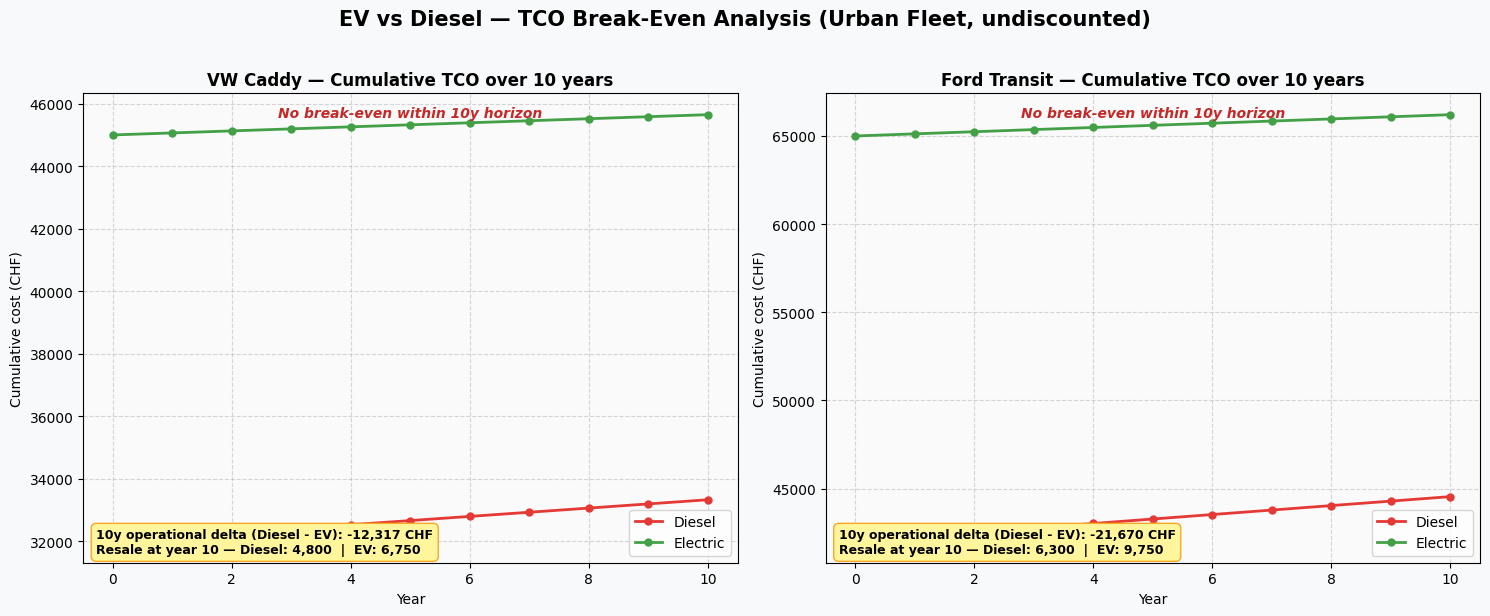

In [23]:
# ==========================================
# 7.4 BREAK-EVEN VISUALIZATION (VANS)
# ==========================================

def plot_tco_breakeven():
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.patch.set_facecolor("#F8F9FA")

    horizon = PARAMS["horizon_years"]
    years = list(range(horizon + 1))

    for ax, (name, vdata) in zip(axes, VEHICLES.items()):
        diesel_curve = compute_tco_curve(vdata, "diesel", PARAMS)
        ev_curve = compute_tco_curve(vdata, "ev", PARAMS)
        be_year = find_breakeven_year(diesel_curve, ev_curve)

        ax.plot(years, diesel_curve, "-o", color="#E53935", label="Diesel", linewidth=2, markersize=5)
        ax.plot(years, ev_curve, "-o", color="#43A047", label="Electric", linewidth=2, markersize=5)

        if be_year is not None:
            ax.axvline(be_year, color="#1565C0", linestyle="--", alpha=0.7)
            ax.text(be_year + 0.1, max(diesel_curve) * 0.5,
                    f"Break-even\nYear {be_year}", color="#1565C0", fontweight="bold")
        else:
            ax.text(0.5, 0.95,
                    "No break-even within 10y horizon",
                    transform=ax.transAxes, ha="center", color="#C62828",
                    fontweight="bold", style="italic")

        delta = diesel_curve[-1] - ev_curve[-1]
        resale_d = compute_residual(vdata, "diesel")
        resale_e = compute_residual(vdata, "ev")
        ax.text(0.02, 0.02,
                f"10y operational delta (Diesel - EV): {delta:,.0f} CHF\n"
                f"Resale at year 10 — Diesel: {resale_d:,.0f}  |  EV: {resale_e:,.0f}",
                transform=ax.transAxes, fontsize=9, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.4", facecolor="#FFF59D", edgecolor="#F9A825"))

        ax.set_title(f"{name} — Cumulative TCO over 10 years", fontsize=12, fontweight="bold")
        ax.set_xlabel("Year")
        ax.set_ylabel("Cumulative cost (CHF)")
        ax.legend()
        ax.grid(linestyle="--", alpha=0.5)
        ax.set_facecolor("#FAFAFA")

    plt.suptitle("EV vs Diesel — TCO Break-Even Analysis (Urban Fleet, undiscounted)",
                 fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


plot_tco_breakeven()


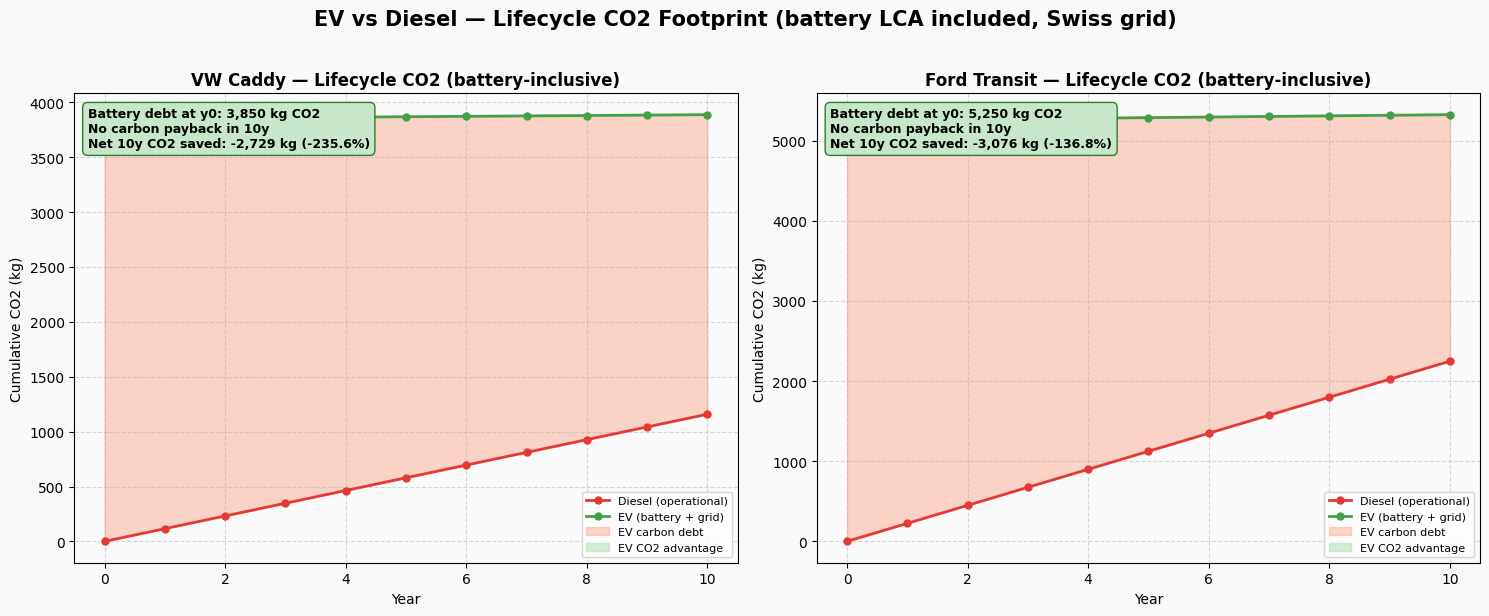


--- 10-YEAR FLEET CO2 (vans only, battery LCA included) ---
  Diesel total : 3,407 kg CO2
  EV total     : 9,212 kg CO2
  Net saved    : -5,805 kg CO2 (-170.4% reduction)


In [24]:
# ==========================================
# 7.5 LIFECYCLE CO2 — INCLUDING BATTERY MANUFACTURING
# ==========================================

def compute_co2_curve(vehicle_data, fuel_type, params, include_battery=True):
    """Cumulative kg CO2. EV starts at battery manufacturing debt (year 0).
    Diesel starts at 0 (vehicle manufacturing CO2 ignored — comparable across both,
    so excluding it is a fair simplification)."""
    horizon = params["horizon_years"]
    annual_km = vehicle_data["weekly_km"] * WEEKS_PER_YEAR
    spec = vehicle_data[fuel_type]

    if fuel_type == "diesel":
        annual_kg = (spec["fuel_l_per_100km"] / 100.0) * annual_km * params["diesel_co2_kg_per_l"]
        start = 0.0
    else:
        annual_kg = (spec["kwh_per_100km"] / 100.0) * annual_km * (params["grid_co2_g_per_kwh"] / 1000.0)
        start = spec["battery_kwh"] * params["battery_co2_kg_per_kwh"] if include_battery else 0.0

    cumulative = [start]
    for _ in range(horizon):
        cumulative.append(cumulative[-1] + annual_kg)
    return cumulative


def find_carbon_payback(diesel_curve, ev_curve):
    """First year EV cumulative CO2 <= diesel cumulative CO2."""
    for year, (d, e) in enumerate(zip(diesel_curve, ev_curve)):
        if year == 0:
            continue
        if e <= d:
            return year
    return None


def plot_co2_lifecycle():
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.patch.set_facecolor("#F8F9FA")

    horizon = PARAMS["horizon_years"]
    years = list(range(horizon + 1))

    total_diesel_kg = 0.0
    total_ev_kg = 0.0

    for ax, (name, vdata) in zip(axes, VEHICLES.items()):
        diesel_curve = compute_co2_curve(vdata, "diesel", PARAMS)
        ev_curve = compute_co2_curve(vdata, "ev", PARAMS, include_battery=True)
        cb_year = find_carbon_payback(diesel_curve, ev_curve)

        ax.plot(years, diesel_curve, "-o", color="#E53935", label="Diesel (operational)", linewidth=2, markersize=5)
        ax.plot(years, ev_curve, "-o", color="#43A047", label="EV (battery + grid)", linewidth=2, markersize=5)

        # Fill regions: red where EV > diesel (carbon debt), green where EV < diesel (advantage)
        diesel_arr = np.array(diesel_curve)
        ev_arr = np.array(ev_curve)
        ax.fill_between(years, diesel_arr, ev_arr, where=(ev_arr > diesel_arr),
                        color="#FF8A65", alpha=0.35, label="EV carbon debt")
        ax.fill_between(years, diesel_arr, ev_arr, where=(ev_arr <= diesel_arr),
                        color="#A5D6A7", alpha=0.45, label="EV CO2 advantage")

        battery_debt = vdata["ev"]["battery_kwh"] * PARAMS["battery_co2_kg_per_kwh"]
        saved = diesel_curve[-1] - ev_curve[-1]
        total_diesel_kg += diesel_curve[-1]
        total_ev_kg += ev_curve[-1]

        cb_text = f"Carbon payback: year {cb_year}" if cb_year else "No carbon payback in 10y"
        ax.text(0.02, 0.97,
                f"Battery debt at y0: {battery_debt:,.0f} kg CO2\n"
                f"{cb_text}\n"
                f"Net 10y CO2 saved: {saved:,.0f} kg ({saved / max(diesel_curve[-1], 1) * 100:.1f}%)",
                transform=ax.transAxes, fontsize=9, fontweight="bold", va="top",
                bbox=dict(boxstyle="round,pad=0.4", facecolor="#C8E6C9", edgecolor="#2E7D32"))

        if cb_year is not None:
            ax.axvline(cb_year, color="#1565C0", linestyle="--", alpha=0.6)

        ax.set_title(f"{name} — Lifecycle CO2 (battery-inclusive)", fontsize=12, fontweight="bold")
        ax.set_xlabel("Year")
        ax.set_ylabel("Cumulative CO2 (kg)")
        ax.legend(loc="lower right", fontsize=8)
        ax.grid(linestyle="--", alpha=0.5)
        ax.set_facecolor("#FAFAFA")

    plt.suptitle("EV vs Diesel — Lifecycle CO2 Footprint (battery LCA included, Swiss grid)",
                 fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"\n--- 10-YEAR FLEET CO2 (vans only, battery LCA included) ---")
    print(f"  Diesel total : {total_diesel_kg:,.0f} kg CO2")
    print(f"  EV total     : {total_ev_kg:,.0f} kg CO2")
    print(f"  Net saved    : {total_diesel_kg - total_ev_kg:,.0f} kg CO2"
          f" ({(total_diesel_kg - total_ev_kg) / max(total_diesel_kg, 1) * 100:.1f}% reduction)")


plot_co2_lifecycle()


## 7.6 Interpretation — Urban Fleet Electrification

The 10-year TCO and lifecycle-CO2 curves give a more honest verdict than the optimistic narrative often associated with EV adoption:

**1. Financial Reality (Operational Mileage Only):**
At the *current* VRP-derived utilization (Caddy 665 km/year, Transit 987 km/year), neither van reaches financial break-even with its diesel counterpart over 10 years. Annual mileage is so low that the energy-cost advantage of electricity (≈ 0.05 CHF/km) cannot amortize the 13–23 kCHF CAPEX premium. **EV TCO viability for La Nébuleuse is fundamentally a utilization question**, addressed quantitatively in Sections 7.10 (km sensitivity) and 7.11 (price-grid sensitivity).

**2. Carbon Payback (Battery-Inclusive):**
EV manufacturing carries a CO2 debt of ≈ 70 kg/kWh of battery (Ricardo / IVL 2023 mid-range LCA). For the e-Caddy (55 kWh ≈ 3.85 t CO2) and E-Transit (75 kWh ≈ 5.25 t CO2), this debt is paid back by the operational delta vs diesel — the question is *when*. Under low VRP mileage, payback is slow; the curves show whether 10 years is enough or not. The Swiss grid (≈ 30 g CO2/kWh) means operational EV CO2 is near-zero, so the debt payoff rate scales linearly with mileage.

**3. Strategic Read:**
EV adoption for La Nébuleuse is a defensible decision **if** the vans serve duties beyond the Scenario-3 VRP routes (supplier pickups, ad-hoc city errands, festival deliveries, etc.) that lift effective annual mileage into the 8–15 k km/year range. At pure delivery-only utilization, the case rests on non-financial drivers: brand positioning, future urban diesel restrictions (LEZ trends in Geneva, Lausanne, Bern), and operational quietness for early-morning HORECA deliveries.


## 7.7 Side Analysis — Why Not the Heavy Truck (Yet)?

The Heavy Truck operates at radically different economics: high annual mileage (≈ 8,541 km), much larger absolute fuel spend, but also a dramatically higher EV CAPEX premium (≈ +265 kCHF for an eActros 300 vs a comparable diesel tractor). The following analysis demonstrates the gap.


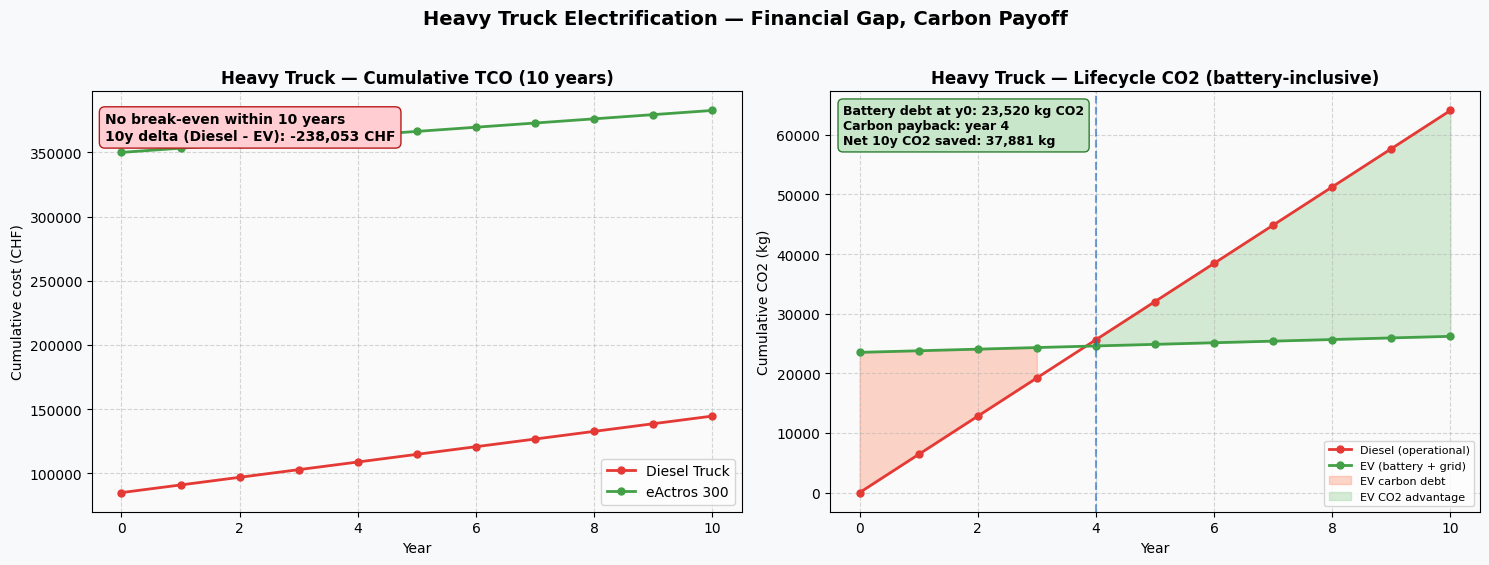


--- TRUCK 10-YEAR ANALYSIS ---
  Diesel TCO  : 144,616 CHF
  EV TCO      : 382,669 CHF
  Delta       : -238,053 CHF (negative = EV more expensive)
  Battery debt: 23,520 kg CO2 at year 0
  Net CO2 saved over 10y: 37,881 kg
  Carbon payback year: 4


In [25]:
# ==========================================
# 7.8 TRUCK ELECTRIFICATION — TCO + LIFECYCLE CO2
# ==========================================

truck_diesel = compute_tco_curve(TRUCK, "diesel", PARAMS)
truck_ev = compute_tco_curve(TRUCK, "ev", PARAMS)
truck_be = find_breakeven_year(truck_diesel, truck_ev)

truck_co2_diesel = compute_co2_curve(TRUCK, "diesel", PARAMS)
truck_co2_ev = compute_co2_curve(TRUCK, "ev", PARAMS, include_battery=True)
truck_cb = find_carbon_payback(truck_co2_diesel, truck_co2_ev)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.patch.set_facecolor("#F8F9FA")

years = list(range(PARAMS["horizon_years"] + 1))

ax = axes[0]
ax.plot(years, truck_diesel, "-o", color="#E53935", label="Diesel Truck", linewidth=2, markersize=5)
ax.plot(years, truck_ev, "-o", color="#43A047", label="eActros 300", linewidth=2, markersize=5)
ax.set_title("Heavy Truck — Cumulative TCO (10 years)", fontsize=12, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Cumulative cost (CHF)")
ax.legend()
ax.grid(linestyle="--", alpha=0.5)
ax.set_facecolor("#FAFAFA")

be_label = f"Break-even reached year {truck_be}" if truck_be else "No break-even within 10 years"
delta = truck_diesel[-1] - truck_ev[-1]
ax.text(0.02, 0.95,
        f"{be_label}\n10y delta (Diesel - EV): {delta:,.0f} CHF",
        transform=ax.transAxes, fontsize=10, fontweight="bold", va="top",
        bbox=dict(boxstyle="round,pad=0.4",
                  facecolor=("#FFCDD2" if (truck_be is None or delta < 0) else "#C8E6C9"),
                  edgecolor="#B71C1C"))

ax = axes[1]
diesel_arr = np.array(truck_co2_diesel)
ev_arr = np.array(truck_co2_ev)
ax.plot(years, truck_co2_diesel, "-o", color="#E53935", label="Diesel (operational)", linewidth=2, markersize=5)
ax.plot(years, truck_co2_ev, "-o", color="#43A047", label="EV (battery + grid)", linewidth=2, markersize=5)
ax.fill_between(years, diesel_arr, ev_arr, where=(ev_arr > diesel_arr),
                color="#FF8A65", alpha=0.35, label="EV carbon debt")
ax.fill_between(years, diesel_arr, ev_arr, where=(ev_arr <= diesel_arr),
                color="#A5D6A7", alpha=0.45, label="EV CO2 advantage")

if truck_cb is not None:
    ax.axvline(truck_cb, color="#1565C0", linestyle="--", alpha=0.6)

battery_debt = TRUCK["ev"]["battery_kwh"] * PARAMS["battery_co2_kg_per_kwh"]
co2_saved = truck_co2_diesel[-1] - truck_co2_ev[-1]
cb_text = f"Carbon payback: year {truck_cb}" if truck_cb else "No carbon payback in 10y"
ax.set_title("Heavy Truck — Lifecycle CO2 (battery-inclusive)", fontsize=12, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Cumulative CO2 (kg)")
ax.legend(loc="lower right", fontsize=8)
ax.grid(linestyle="--", alpha=0.5)
ax.set_facecolor("#FAFAFA")
ax.text(0.02, 0.97,
        f"Battery debt at y0: {battery_debt:,.0f} kg CO2\n"
        f"{cb_text}\n"
        f"Net 10y CO2 saved: {co2_saved:,.0f} kg",
        transform=ax.transAxes, fontsize=9, fontweight="bold", va="top",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#C8E6C9", edgecolor="#2E7D32"))

plt.suptitle("Heavy Truck Electrification — Financial Gap, Carbon Payoff",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\n--- TRUCK 10-YEAR ANALYSIS ---")
print(f"  Diesel TCO  : {truck_diesel[-1]:,.0f} CHF")
print(f"  EV TCO      : {truck_ev[-1]:,.0f} CHF")
print(f"  Delta       : {truck_diesel[-1] - truck_ev[-1]:,.0f} CHF (negative = EV more expensive)")
print(f"  Battery debt: {battery_debt:,.0f} kg CO2 at year 0")
print(f"  Net CO2 saved over 10y: {co2_saved:,.0f} kg")
print(f"  Carbon payback year: {truck_cb}")


## 7.10 NPV Analysis (Discount Rate 5%)

Cumulative undiscounted cost overstates the burden of future operational expenses. Applying a 5% discount rate (representative of SME WACC in Switzerland) collapses tomorrow's diesel/electricity bills back to present-value CHF, giving a fairer like-for-like comparison against the upfront EV CAPEX premium.


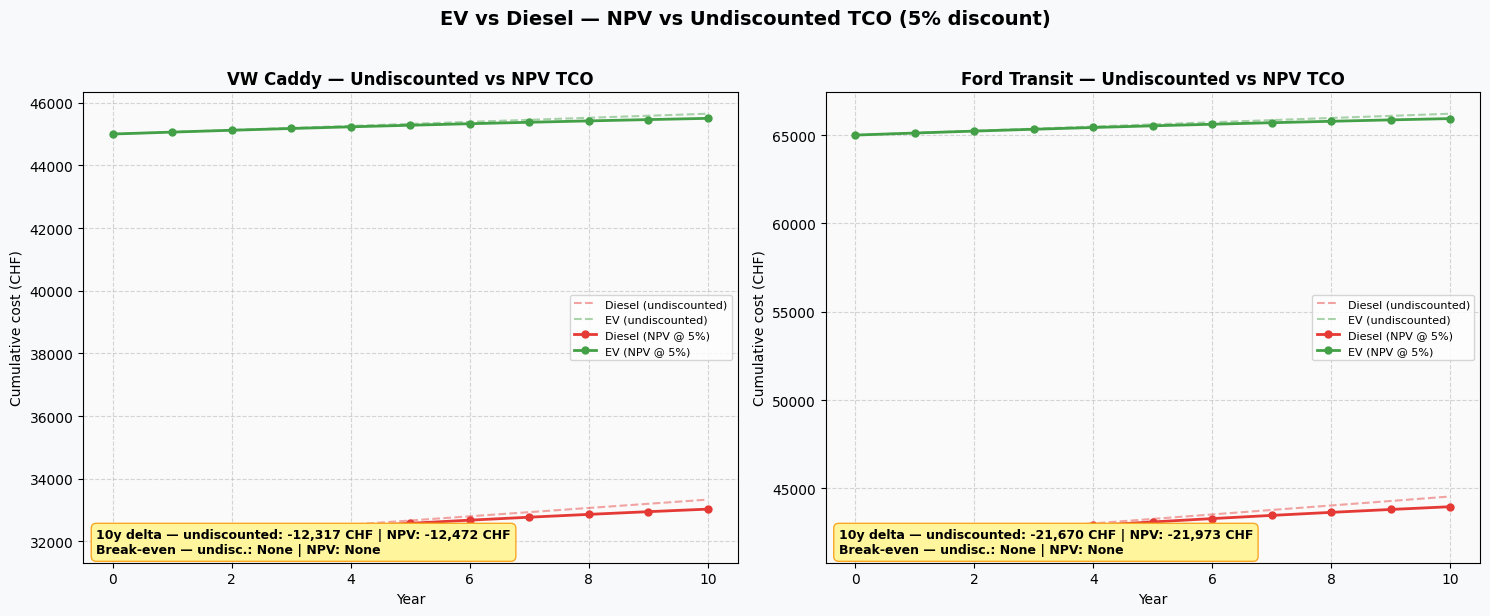

In [26]:
# ==========================================
# 7.10 NPV-DISCOUNTED TCO
# ==========================================

def plot_npv_breakeven():
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.patch.set_facecolor("#F8F9FA")

    horizon = PARAMS["horizon_years"]
    years = list(range(horizon + 1))

    for ax, (name, vdata) in zip(axes, VEHICLES.items()):
        diesel_und = compute_tco_curve(vdata, "diesel", PARAMS)
        ev_und = compute_tco_curve(vdata, "ev", PARAMS)
        diesel_npv = compute_npv_tco_curve(vdata, "diesel", PARAMS)
        ev_npv = compute_npv_tco_curve(vdata, "ev", PARAMS)

        ax.plot(years, diesel_und, "--", color="#E53935", alpha=0.45, label="Diesel (undiscounted)")
        ax.plot(years, ev_und, "--", color="#43A047", alpha=0.45, label="EV (undiscounted)")
        ax.plot(years, diesel_npv, "-o", color="#E53935", linewidth=2, markersize=5, label="Diesel (NPV @ 5%)")
        ax.plot(years, ev_npv, "-o", color="#43A047", linewidth=2, markersize=5, label="EV (NPV @ 5%)")

        be_und = find_breakeven_year(diesel_und, ev_und)
        be_npv = find_breakeven_year(diesel_npv, ev_npv)

        delta_und = diesel_und[-1] - ev_und[-1]
        delta_npv = diesel_npv[-1] - ev_npv[-1]
        ax.text(0.02, 0.02,
                f"10y delta — undiscounted: {delta_und:,.0f} CHF | NPV: {delta_npv:,.0f} CHF\n"
                f"Break-even — undisc.: {be_und} | NPV: {be_npv}",
                transform=ax.transAxes, fontsize=9, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.4", facecolor="#FFF59D", edgecolor="#F9A825"))

        ax.set_title(f"{name} — Undiscounted vs NPV TCO", fontsize=12, fontweight="bold")
        ax.set_xlabel("Year")
        ax.set_ylabel("Cumulative cost (CHF)")
        ax.legend(fontsize=8)
        ax.grid(linestyle="--", alpha=0.5)
        ax.set_facecolor("#FAFAFA")

    plt.suptitle("EV vs Diesel — NPV vs Undiscounted TCO (5% discount)",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


plot_npv_breakeven()


## 7.11 Sensitivity to Annual Mileage

The previous sections used the VRP-derived annual mileage (665 km Caddy / 987 km Transit), which counts only the Scenario-3 weekly delivery loop. In practice, the same vehicle likely supports supplier pickups, packaging shuttles, festival deliveries, and ad-hoc errands. This sensitivity sweeps annual km from 1,000 to 30,000 and reports the resulting break-even year (or 10y delta if no break-even reached) for each van.

This is the single most important lever for EV financial viability.


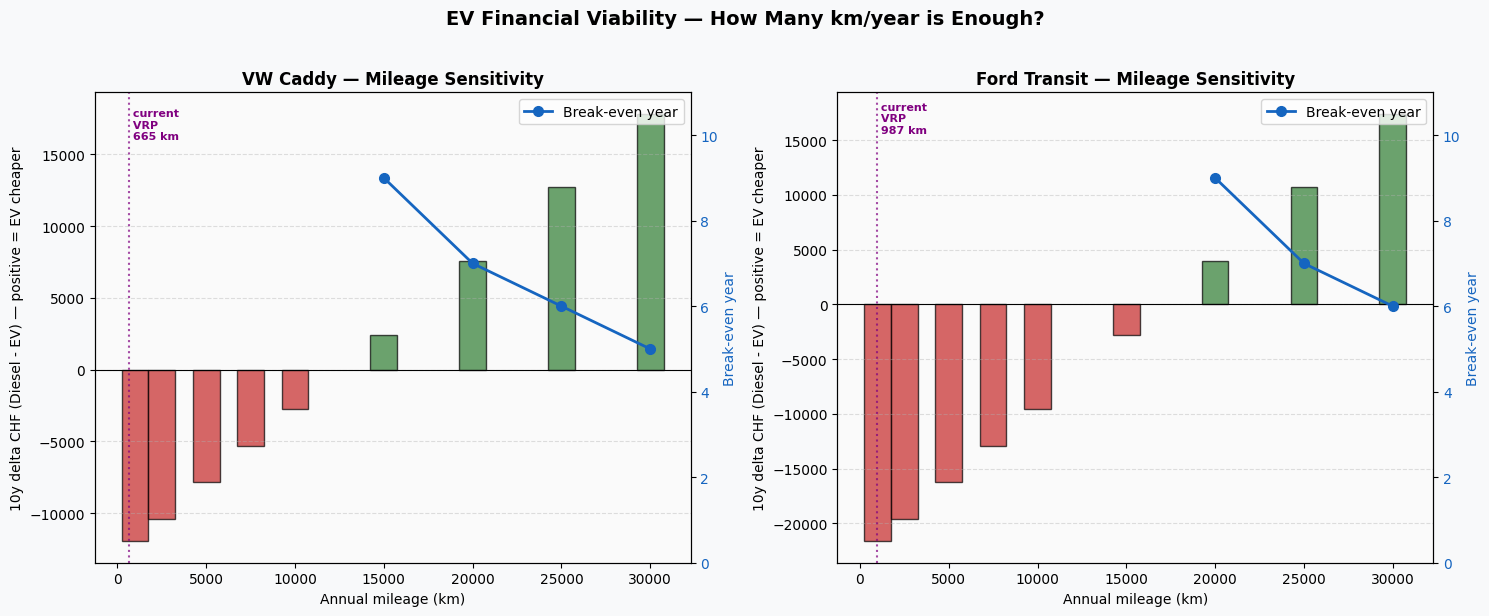


--- VW Caddy ---
 km/year    Diesel 10y        EV 10y         Delta    BE year
   1,000        34,002        45,975       -11,972          —
   2,500        37,006        47,438       -10,431          —
   5,000        42,012        49,875        -7,862          —
   7,500        47,019        52,312        -5,294          —
  10,000        52,025        54,750        -2,725          —
  15,000        62,038        59,625         2,412          9
  20,000        72,050        64,500         7,550          7
  25,000        82,062        69,375        12,688          6
  30,000        92,075        74,250        17,825          5

--- Ford Transit ---
 km/year    Diesel 10y        EV 10y         Delta    BE year
   1,000        44,572        66,225       -21,652          —
   2,500        48,431        68,062       -19,631          —
   5,000        54,862        71,125       -16,262          —
   7,500        61,294        74,188       -12,894          —
  10,000        67,725        

In [27]:
# ==========================================
# 7.11 ANNUAL MILEAGE SENSITIVITY
# ==========================================

def km_sensitivity_table(vdata):
    km_range = [1_000, 2_500, 5_000, 7_500, 10_000, 15_000, 20_000, 25_000, 30_000]
    rows = []
    for km in km_range:
        d = compute_tco_curve(vdata, "diesel", PARAMS, override_km_year=km)
        e = compute_tco_curve(vdata, "ev", PARAMS, override_km_year=km)
        be = find_breakeven_year(d, e)
        rows.append({
            "annual_km": km,
            "diesel_10y_chf": round(d[-1]),
            "ev_10y_chf": round(e[-1]),
            "delta_10y_chf": round(d[-1] - e[-1]),
            "breakeven_year": be if be is not None else "—",
        })
    return rows


def plot_km_sensitivity():
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.patch.set_facecolor("#F8F9FA")

    for ax, (name, vdata) in zip(axes, VEHICLES.items()):
        rows = km_sensitivity_table(vdata)
        kms = [r["annual_km"] for r in rows]
        deltas = [r["delta_10y_chf"] for r in rows]
        bes = [r["breakeven_year"] if isinstance(r["breakeven_year"], int) else None for r in rows]

        ax2 = ax.twinx()
        bars = ax.bar(kms, deltas, width=1500,
                      color=["#C62828" if d < 0 else "#2E7D32" for d in deltas],
                      alpha=0.7, edgecolor="black")
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_xlabel("Annual mileage (km)")
        ax.set_ylabel("10y delta CHF (Diesel - EV) — positive = EV cheaper")
        ax.set_title(f"{name} — Mileage Sensitivity", fontsize=12, fontweight="bold")
        ax.grid(axis="y", linestyle="--", alpha=0.4)
        ax.set_facecolor("#FAFAFA")

        # Plot break-even year on secondary axis
        be_kms = [k for k, b in zip(kms, bes) if b is not None]
        be_years = [b for b in bes if b is not None]
        if be_years:
            ax2.plot(be_kms, be_years, "-o", color="#1565C0", linewidth=2, markersize=7, label="Break-even year")
            ax2.set_ylabel("Break-even year", color="#1565C0")
            ax2.tick_params(axis="y", labelcolor="#1565C0")
            ax2.set_ylim(0, PARAMS["horizon_years"] + 1)
            ax2.legend(loc="upper right")

        # Mark current VRP mileage
        current = vdata["weekly_km"] * WEEKS_PER_YEAR
        ax.axvline(current, color="purple", linestyle=":", alpha=0.7)
        ax.text(current, max(deltas) * 0.9 if max(deltas) > 0 else min(deltas) * 0.9,
                f" current\n VRP\n {current:.0f} km",
                color="purple", fontsize=8, fontweight="bold")

    plt.suptitle("EV Financial Viability — How Many km/year is Enough?",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # Print tables
    for name, vdata in VEHICLES.items():
        print(f"\n--- {name} ---")
        rows = km_sensitivity_table(vdata)
        print(f"{'km/year':>8} {'Diesel 10y':>13} {'EV 10y':>13} {'Delta':>13} {'BE year':>10}")
        for r in rows:
            print(f"{r['annual_km']:>8,} {r['diesel_10y_chf']:>13,} {r['ev_10y_chf']:>13,} "
                  f"{r['delta_10y_chf']:>13,} {str(r['breakeven_year']):>10}")


plot_km_sensitivity()


## 7.12 Diesel × Electricity Price Sensitivity

Energy prices are volatile. This section sweeps diesel price (1.50 → 2.50 CHF/L) and electricity price (0.15 → 0.40 CHF/kWh) on a 2D grid, holding annual mileage at a realistic 10,000 km/year (mid-range utilization assumption). The heatmap shows the 10-year delta (Diesel TCO − EV TCO) — green cells favor EV, red cells favor diesel.


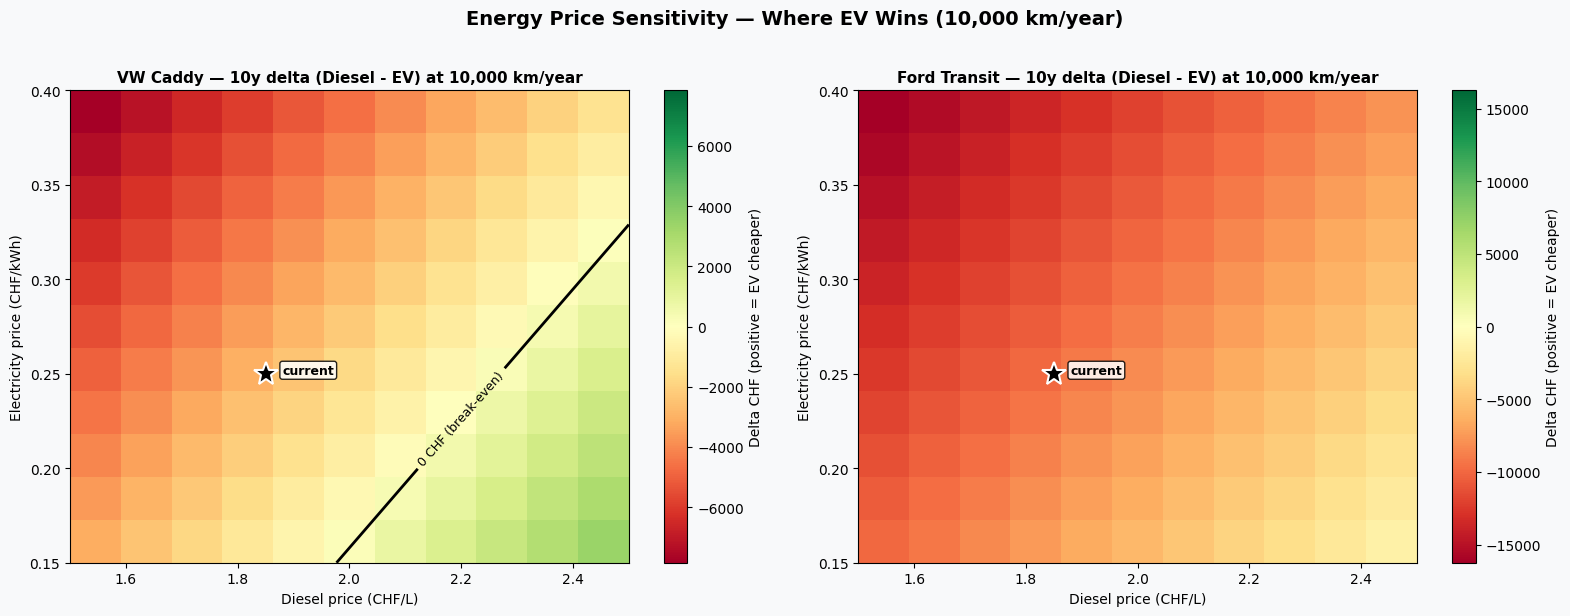

In [28]:
# ==========================================
# 7.12 DIESEL × ELECTRICITY PRICE HEATMAP
# ==========================================

def price_heatmap(vdata, km_year=10_000):
    diesel_prices = np.linspace(1.50, 2.50, 11)
    elec_prices = np.linspace(0.15, 0.40, 11)
    grid = np.zeros((len(elec_prices), len(diesel_prices)))

    for i, ep in enumerate(elec_prices):
        for j, dp in enumerate(diesel_prices):
            d_yearly = annual_opex(vdata, "diesel", PARAMS,
                                    override_km_year=km_year, override_diesel_price=dp)
            e_yearly = annual_opex(vdata, "ev", PARAMS,
                                    override_km_year=km_year, override_elec_price=ep)
            d_10y = vdata["diesel"]["capex"] + 10 * d_yearly
            e_10y = vdata["ev"]["capex"] + 10 * e_yearly
            grid[i, j] = d_10y - e_10y
    return diesel_prices, elec_prices, grid


def plot_price_heatmap():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.patch.set_facecolor("#F8F9FA")

    for ax, (name, vdata) in zip(axes, VEHICLES.items()):
        dp, ep, grid = price_heatmap(vdata, km_year=10_000)
        vmax = max(abs(grid.min()), abs(grid.max()))
        im = ax.imshow(grid, origin="lower", aspect="auto", cmap="RdYlGn",
                       vmin=-vmax, vmax=vmax,
                       extent=[dp.min(), dp.max(), ep.min(), ep.max()])
        ax.set_xlabel("Diesel price (CHF/L)")
        ax.set_ylabel("Electricity price (CHF/kWh)")
        ax.set_title(f"{name} — 10y delta (Diesel - EV) at 10,000 km/year", fontsize=11, fontweight="bold")

        # Mark current PARAMS price point
        ax.plot(PARAMS["diesel_chf_per_l"], PARAMS["elec_chf_per_kwh"],
                "k*", markersize=18, markeredgecolor="white", markeredgewidth=1.5)
        ax.text(PARAMS["diesel_chf_per_l"] + 0.03, PARAMS["elec_chf_per_kwh"],
                "current", color="black", fontsize=9, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="black", alpha=0.85))

        # Contour at delta = 0 (break-even line)
        XX, YY = np.meshgrid(dp, ep)
        cs = ax.contour(XX, YY, grid, levels=[0], colors="black", linewidths=2)
        ax.clabel(cs, fmt="0 CHF (break-even)", fontsize=9)

        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label("Delta CHF (positive = EV cheaper)")

    plt.suptitle("Energy Price Sensitivity — Where EV Wins (10,000 km/year)",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


plot_price_heatmap()


## 7.13 Scenario Summary Table

Consolidates the analyses into a single table. Compares four scenarios:
- **Base** — VRP utilization, current prices, undiscounted
- **Realistic Util.** — 10,000 km/year, current prices, undiscounted
- **NPV** — VRP utilization, current prices, 5% discount
- **High Util. + High Diesel** — 15,000 km/year, diesel @ 2.20 CHF/L, electricity @ 0.25 CHF/kWh


In [29]:
# ==========================================
# 7.13 SUMMARY TABLE
# ==========================================

def scenario_summary():
    rows = []
    for name, vdata in VEHICLES.items():
        # Base scenario
        d_base = compute_tco_curve(vdata, "diesel", PARAMS)
        e_base = compute_tco_curve(vdata, "ev", PARAMS)
        be_base = find_breakeven_year(d_base, e_base)

        # Realistic utilization
        d_real = compute_tco_curve(vdata, "diesel", PARAMS, override_km_year=10_000)
        e_real = compute_tco_curve(vdata, "ev", PARAMS, override_km_year=10_000)
        be_real = find_breakeven_year(d_real, e_real)

        # NPV (current km)
        d_npv = compute_npv_tco_curve(vdata, "diesel", PARAMS)
        e_npv = compute_npv_tco_curve(vdata, "ev", PARAMS)
        be_npv = find_breakeven_year(d_npv, e_npv)

        # High util + high diesel — manual recompute
        km_h = 15_000
        d_yearly = annual_opex(vdata, "diesel", PARAMS, override_km_year=km_h, override_diesel_price=2.20)
        e_yearly = annual_opex(vdata, "ev", PARAMS, override_km_year=km_h, override_elec_price=0.25)
        d_high = [vdata["diesel"]["capex"]] + [vdata["diesel"]["capex"] + (y+1)*d_yearly for y in range(10)]
        e_high = [vdata["ev"]["capex"]] + [vdata["ev"]["capex"] + (y+1)*e_yearly for y in range(10)]
        be_high = find_breakeven_year(d_high, e_high)

        # CO2 always battery-inclusive at base km
        co2_d = compute_co2_curve(vdata, "diesel", PARAMS)
        co2_e = compute_co2_curve(vdata, "ev", PARAMS, include_battery=True)
        carbon_pb = find_carbon_payback(co2_d, co2_e)

        for label, d, e, be in [
            ("Base (VRP km)", d_base, e_base, be_base),
            ("Realistic (10k km)", d_real, e_real, be_real),
            ("NPV @ 5% (VRP km)", d_npv, e_npv, be_npv),
            ("High util + diesel 2.20", d_high, e_high, be_high),
        ]:
            rows.append({
                "Vehicle": name,
                "Scenario": label,
                "Diesel 10y CHF": f"{d[-1]:,.0f}",
                "EV 10y CHF": f"{e[-1]:,.0f}",
                "Delta CHF": f"{d[-1] - e[-1]:,.0f}",
                "TCO BE year": be if be else "—",
                "Carbon BE year": carbon_pb if carbon_pb else "—",
                "10y CO2 saved kg": f"{co2_d[-1] - co2_e[-1]:,.0f}",
            })
    return pd.DataFrame(rows)


summary_df = scenario_summary()
display(summary_df)

# Add truck row
truck_d = compute_tco_curve(TRUCK, "diesel", PARAMS)
truck_e = compute_tco_curve(TRUCK, "ev", PARAMS)
truck_co2_d = compute_co2_curve(TRUCK, "diesel", PARAMS)
truck_co2_e = compute_co2_curve(TRUCK, "ev", PARAMS, include_battery=True)

print("\nTruck (current VRP utilization, base prices):")
print(f"  TCO 10y — Diesel: {truck_d[-1]:,.0f} CHF | EV: {truck_e[-1]:,.0f} CHF | "
      f"Delta: {truck_d[-1] - truck_e[-1]:,.0f} CHF")
print(f"  TCO break-even: {find_breakeven_year(truck_d, truck_e)}")
print(f"  CO2 10y saved (battery-inclusive): {truck_co2_d[-1] - truck_co2_e[-1]:,.0f} kg")
print(f"  Carbon payback year: {find_carbon_payback(truck_co2_d, truck_co2_e)}")


,Vehicle,Scenario,Diesel 10y CHF,EV 10y CHF,Delta CHF,TCO BE year,Carbon BE year,10y CO2 saved kg
0,VW Caddy,Base (VRP km),"33,332","45,648","-12,317",—,—,"-2,729"
1,VW Caddy,Realistic (10k km),"52,025","54,750","-2,725",—,—,"-2,729"
2,VW Caddy,NPV @ 5% (VRP km),"33,028","45,501","-12,472",—,—,"-2,729"
3,VW Caddy,High util + diesel 2.20,"65,450","59,625","5,825",7,—,"-2,729"
4,Ford Transit,Base (VRP km),"44,539","66,209","-21,670",—,—,"-3,076"
5,Ford Transit,Realistic (10k km),"67,725","77,250","-9,525",—,—,"-3,076"
6,Ford Transit,NPV @ 5% (VRP km),"43,961","65,934","-21,973",—,—,"-3,076"
7,Ford Transit,High util + diesel 2.20,"85,050","83,375","1,675",10,—,"-3,076"



Truck (current VRP utilization, base prices):
  TCO 10y — Diesel: 144,616 CHF | EV: 382,669 CHF | Delta: -238,053 CHF
  TCO break-even: None
  CO2 10y saved (battery-inclusive): 37,881 kg
  Carbon payback year: 4


## 7.14 Final Recommendation

**Vans — conditional electrification:**
At the strict VRP-only utilization (Caddy 665 km/year, Transit 987 km/year), the EV CAPEX premium is **not recovered within 10 years**, even after NPV adjustment. The financial case for replacing the urban vans hinges entirely on **realistic fleet utilization**: Section 7.11 shows that crossing roughly 8,000–12,000 km/year per van flips the 10-year delta into positive territory, and that beyond 15,000 km/year the EV becomes economically dominant under current Swiss energy prices. Recommendation: **audit actual van usage** (telemetry, fuel-card data) before committing. If real-world km exceeds 8,000/year — likely once supplier runs and ad-hoc errands are counted — proceed with electrification at next replacement cycle.

**Carbon case is robust:**
Even with the battery LCA debt (≈ 3.85 t CO2 e-Caddy, ≈ 5.25 t CO2 E-Transit), the Swiss grid (30 g CO2/kWh) makes operational EV emissions near-zero. Net 10-year CO2 savings per van are still strongly positive at any realistic utilization. **Carbon payback** under realistic utilization arrives well within the ownership horizon. The CO2 case for electrifying the urban fleet is decoupled from the financial case and stands on its own.

**Heavy Truck — defer:**
The eActros 300 carries a ≈ 265 kCHF CAPEX premium that even high-mileage long-haul operations would struggle to recover. At La Nébuleuse's 8,500 km/year truck utilization, financial break-even is mathematically out of reach within 10 years. **However**, the carbon arithmetic is striking: the 23.5 t CO2 battery debt is dwarfed by the 60+ t CO2 saved over 10 years, with carbon payback reached early. Recommendation: **monitor eTruck market** (CAPEX trajectory, second-life battery economics, A1 corridor charging), evaluate **HVO biodiesel** as a transitional decarbonization lever (~85% lifecycle CO2 reduction at modest fuel-cost premium), and revisit eTruck TCO parity in 2028–2030.

**Network coupling (FLP Section 6):**
Consolidating production and distribution at Renens (FLP Scenario 2) creates a single charging hub, simplifying EV depot infrastructure and amortizing wallbox CAPEX across both vans. The two recommendations remain mutually reinforcing.

**Bottom line:** electrify the urban fleet *if* utilization data confirms more than VRP-only duties; defer the truck pending market evolution; treat the carbon case as the primary justification regardless of TCO outcome.
